# ML Assignment 2: Combined Model Notebook

This notebook contains the complete pipeline:
1. **Data Loading & Feature Extraction**
2. **Exploratory Data Analysis**
3. **Data Saving & Temporal Split**
4. **Model 1: Support Vector Machine (SVM)**
5. **Model 2: Decision Tree**
6. **Model 3: Neural Network (MLP from Scratch)**


# ML Assignment 2: Data Merging & Exploratory Data Analysis

**Goal**: Merge the 6 CSV tables into a unified patient-level dataset and perform EDA.

**Target**: Multi-label classification: predict which diseases a patient has (output = binary vector).

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

## 1. Load Raw Data

In [142]:
print("Loading datasets...")
patients = pd.read_csv('csv/patients.csv', on_bad_lines='skip')
conditions = pd.read_csv('csv/conditions.csv', on_bad_lines='skip')
conditions = conditions.loc[:, ~conditions.columns.str.startswith('Unnamed')]
encounters = pd.read_csv('csv/encounters.csv', on_bad_lines='skip')
medications = pd.read_csv('csv/medications.csv', on_bad_lines='skip')
procedures = pd.read_csv('csv/procedures.csv', on_bad_lines='skip')

print(f"patients:    {patients.shape}")
print(f"conditions:  {conditions.shape}")
print(f"encounters:  {encounters.shape}")
print(f"medications: {medications.shape}")
print(f"procedures:  {procedures.shape}")
print("\nPatients columns:", list(patients.columns))
print("Conditions columns:", list(conditions.columns))

Loading datasets...
patients:    (2823, 28)
conditions:  (3238, 7)
encounters:  (126048, 15)
medications: (102402, 13)
procedures:  (343112, 10)

Patients columns: ['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']
Conditions columns: ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE', 'DESCRIPTION']


## 2. Feature Extraction
### 2.1 Patient Demographics
Extract: Age, Gender, Race, Ethnicity, Income, Healthcare costs, Alive status

In [143]:
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'], errors='coerce')
patients['AGE'] = ((pd.Timestamp.now() - patients['BIRTHDATE']).dt.days / 365.25).astype(int)
patients['IS_ALIVE'] = patients['DEATHDATE'].isna().astype(int)

patient_features = patients[['Id', 'AGE', 'GENDER', 'RACE', 'ETHNICITY',
                              'INCOME', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE',
                              'IS_ALIVE']].copy()
patient_features.rename(columns={'Id': 'PATIENT'}, inplace=True)

print(f"Patient features: {patient_features.shape}")
print(patient_features.describe())

Patient features: (2823, 9)
               AGE         INCOME  HEALTHCARE_EXPENSES  HEALTHCARE_COVERAGE  \
count  2823.000000    2823.000000         2.823000e+03         2.823000e+03   
mean     44.636557  112501.434290         1.823625e+05         3.327227e+05   
std      26.309793  163473.018956         2.454355e+05         4.198050e+05   
min       0.000000     110.000000         1.000000e+02         0.000000e+00   
25%      23.000000   29837.500000         2.100058e+04         2.381056e+04   
50%      44.000000   67600.000000         9.611757e+04         1.636165e+05   
75%      63.000000  122814.000000         2.213576e+05         5.375056e+05   
max     110.000000  994653.000000         1.773785e+06         3.442973e+06   

          IS_ALIVE  
count  2823.000000  
mean      0.869288  
std       0.337145  
min       0.000000  
25%       1.000000  
50%       1.000000  
75%       1.000000  
max       1.000000  


### 2.2 Multi-Label Disease Target (from Conditions)

Group conditions into disease categories. Each patient gets a binary vector
indicating which disease groups they have (1) or don't have (0).

Patients NOT in the conditions table are treated as "healthy" (all zeros).

In [144]:
# Disease groups with keyword matching
disease_groups = {
    'Hypertension': ['hypertension'],
    'Diabetes': ['diabetes', 'prediabetes', 'hyperglycemia'],
    'Obesity': ['obesity', 'body mass index 30', 'body mass index 40'],
    'Anemia': ['anemia'],
    'Respiratory': ['sinusitis', 'bronchitis', 'pharyngitis', 'asthma', 'pneumonia'],
    'Heart_Disease': ['myocardial infarction', 'heart failure', 'atrial fibrillation', 'coronary heart'],
    'Kidney_Disease': ['kidney disease'],
    'Cancer': ['neoplasm', 'carcinoma', 'cancer'],
    'Dental': ['gingivitis', 'gingival disease', 'dental caries'],
}

all_patients = patient_features['PATIENT'].unique()
target_df = pd.DataFrame({'PATIENT': all_patients})

print("Disease group patient counts:")
for group, keywords in disease_groups.items():
    mask = conditions['DESCRIPTION'].str.lower().apply(
        lambda x: any(kw in str(x) for kw in keywords)
    )
    positive_patients = set(conditions.loc[mask, 'PATIENT'].unique())
    target_df[f'TARGET_{group}'] = target_df['PATIENT'].isin(positive_patients).astype(int)
    print(f"  {group}: {target_df[f'TARGET_{group}'].sum()} patients")

# Drop disease groups with too few patients (< 5)
target_cols = [c for c in target_df.columns if c.startswith('TARGET_')]
drop_cols = [c for c in target_cols if target_df[c].sum() < 5]
if drop_cols:
    print(f"\nDropped (< 5 patients): {[c.replace('TARGET_', '') for c in drop_cols]}")
    target_df.drop(columns=drop_cols, inplace=True)

# Summary
target_cols = [c for c in target_df.columns if c.startswith('TARGET_')]
target_df['HAS_ANY_DISEASE'] = (target_df[target_cols].sum(axis=1) > 0).astype(int)
target_df['NUM_DISEASES'] = target_df[target_cols].sum(axis=1)
print(f"\nPatients with any disease: {target_df['HAS_ANY_DISEASE'].sum()} / {len(target_df)}")
print(f"Max diseases per patient: {target_df['NUM_DISEASES'].max()}")

Disease group patient counts:
  Hypertension: 24 patients
  Diabetes: 43 patients
  Obesity: 44 patients
  Anemia: 42 patients
  Respiratory: 95 patients
  Heart_Disease: 12 patients
  Kidney_Disease: 7 patients
  Cancer: 4 patients
  Dental: 93 patients

Dropped (< 5 patients): ['Cancer']

Patients with any disease: 103 / 2823
Max diseases per patient: 8


### 2.3 Clinical Observations

The observations file is large (~271MB, 1.5M rows). We read in chunks,
filter to key numeric observations, and aggregate per patient (mean, std).

In [145]:
key_obs = [
    'Body Height', 'Body Weight', 'Body mass index (BMI) [Ratio]',
    'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Heart rate', 'Respiratory rate',
    'Glucose [Mass/volume] in Blood',
    'Hemoglobin A1c/Hemoglobin.total in Blood',
    'Creatinine [Mass/volume] in Blood',
    'Calcium [Mass/volume] in Blood',
    'Sodium [Moles/volume] in Blood',
    'Potassium [Moles/volume] in Blood',
    'Chloride [Moles/volume] in Blood',
    'Urea nitrogen [Mass/volume] in Blood',
    'Pain severity - 0-10 verbal numeric rating [Score] - Reported',
    'Patient Health Questionnaire 2 item (PHQ-2) total score [Reported]',
    'DALY', 'QALY', 'QOLS',
]

short_names = {
    'Body Height': 'height', 'Body Weight': 'weight',
    'Body mass index (BMI) [Ratio]': 'bmi',
    'Systolic Blood Pressure': 'sbp', 'Diastolic Blood Pressure': 'dbp',
    'Heart rate': 'heart_rate', 'Respiratory rate': 'resp_rate',
    'Glucose [Mass/volume] in Blood': 'glucose',
    'Hemoglobin A1c/Hemoglobin.total in Blood': 'hba1c',
    'Creatinine [Mass/volume] in Blood': 'creatinine',
    'Calcium [Mass/volume] in Blood': 'calcium',
    'Sodium [Moles/volume] in Blood': 'sodium',
    'Potassium [Moles/volume] in Blood': 'potassium',
    'Chloride [Moles/volume] in Blood': 'chloride',
    'Urea nitrogen [Mass/volume] in Blood': 'bun',
    'Pain severity - 0-10 verbal numeric rating [Score] - Reported': 'pain',
    'Patient Health Questionnaire 2 item (PHQ-2) total score [Reported]': 'phq2',
    'DALY': 'daly', 'QALY': 'qaly', 'QOLS': 'qols',
}

print("Processing observations (chunked reading)...")
chunks = []
for i, chunk in enumerate(pd.read_csv('csv/observations.csv', chunksize=200000, on_bad_lines='skip')):
    numeric = chunk[chunk['TYPE'] == 'numeric'].copy()
    numeric['VALUE'] = pd.to_numeric(numeric['VALUE'], errors='coerce')
    numeric = numeric.dropna(subset=['VALUE'])
    filtered = numeric[numeric['DESCRIPTION'].isin(key_obs)]
    if len(filtered) > 0:
        chunks.append(filtered[['PATIENT', 'DESCRIPTION', 'VALUE']])
    print(f"  Chunk {i+1}/8 processed...", end='\r')

obs_data = pd.concat(chunks, ignore_index=True)
obs_data['DESCRIPTION'] = obs_data['DESCRIPTION'].map(short_names)
print(f"\nFiltered observations: {len(obs_data):,} rows, {obs_data.PATIENT.nunique()} patients")

# Aggregate per patient: mean and std
obs_agg = obs_data.groupby(['PATIENT', 'DESCRIPTION'])['VALUE'].agg(['mean', 'std']).reset_index()
obs_agg['std'] = obs_agg['std'].fillna(0)

obs_mean = obs_agg.pivot_table(index='PATIENT', columns='DESCRIPTION', values='mean')
obs_mean.columns = [f'{c}_mean' for c in obs_mean.columns]
obs_std = obs_agg.pivot_table(index='PATIENT', columns='DESCRIPTION', values='std')
obs_std.columns = [f'{c}_std' for c in obs_std.columns]
obs_features = obs_mean.join(obs_std).reset_index()

print(f"Observation features: {obs_features.shape}")
obs_features.head()

Processing observations (chunked reading)...
  Chunk 8/8 processed...
Filtered observations: 462,582 rows, 2206 patients
Observation features: (2206, 41)


,PATIENT,bmi_mean,bun_mean,calcium_mean,chloride_mean,creatinine_mean,daly_mean,dbp_mean,glucose_mean,hba1c_mean,...,height_std,pain_std,phq2_std,potassium_std,qaly_std,qols_std,resp_rate_std,sbp_std,sodium_std,weight_std
0,00043074-bbc9-7d65-195e-e615d7b61dcb,29.433333,13.2,9.633333,103.833333,1.033333,0.00,76.555556,86.583333,6.066667,...,0.000000,0.836660,0.547723,0.280476,3.027650,0.000000,1.048809,15.754188,1.990645,3.029026
1,0033b4c0-255c-af66-8fc9-ebe17f725461,24.540000,NaN,NaN,NaN,NaN,0.00,74.400000,NaN,NaN,...,0.000000,1.414214,0.836660,NaN,3.316625,0.000000,1.000000,6.140033,NaN,5.799397
2,0050e373-575d-88b8-f682-64abf43ae57e,18.991667,NaN,NaN,NaN,NaN,0.08,66.166667,NaN,NaN,...,17.840427,0.996205,NaN,NaN,2.998444,0.031623,0.753778,3.848455,NaN,12.761756
3,0054eccc-84f7-ff56-75cf-d4dc86f63a7a,15.683333,NaN,NaN,NaN,NaN,0.00,83.583333,NaN,NaN,...,20.271917,1.083625,NaN,NaN,3.027650,0.000000,1.403459,4.621262,NaN,10.833310
4,00a56f5f-4707-007f-9132-bf26fd1ceee8,26.793617,NaN,NaN,NaN,NaN,0.45,84.106383,NaN,NaN,...,6.305410,0.870260,0.000000,NaN,2.846147,0.042164,1.172604,5.988039,NaN,4.665522


### 2.4 Encounters, Medications & Procedures

Extract count-based and cost-based features per patient from each table.

In [146]:
encounter_features = encounters.groupby('PATIENT').agg(
    total_encounters=('Id', 'count'),
    unique_enc_types=('ENCOUNTERCLASS', 'nunique'),
    total_claim_cost=('TOTAL_CLAIM_COST', 'sum'),
    avg_claim_cost=('TOTAL_CLAIM_COST', 'mean'),
    total_payer_coverage=('PAYER_COVERAGE', 'sum'),
).reset_index()

# Encounter type counts (ambulatory, emergency, inpatient, etc.)
enc_types = encounters.groupby(['PATIENT', 'ENCOUNTERCLASS']).size().unstack(fill_value=0)
enc_types.columns = [f'enc_{c}' for c in enc_types.columns]
enc_types = enc_types.reset_index()
encounter_features = encounter_features.merge(enc_types, on='PATIENT', how='left')
print(f"Encounter features: {encounter_features.shape}")

Encounter features: (2275, 16)


In [147]:
med_features = medications.groupby('PATIENT').agg(
    total_medications=('CODE', 'count'),
    unique_medications=('DESCRIPTION', 'nunique'),
    total_med_cost=('TOTALCOST', 'sum'),
    avg_dispenses=('DISPENSES', 'mean'),
).reset_index()
print(f"Medication features: {med_features.shape}")

Medication features: (2374, 5)


In [148]:
proc_features = procedures.groupby('PATIENT').agg(
    total_procedures=('CODE', 'count'),
    unique_procedures=('DESCRIPTION', 'nunique'),
    total_proc_cost=('BASE_COST', 'sum'),
).reset_index()
print(f"Procedure features: {proc_features.shape}")

Procedure features: (2482, 4)


## 3. Merge into Unified Patient-Level Dataset

Left-join everything onto the patient table so we keep all 2823 patients.
Patients without data in a table get NaN (filled appropriately).

In [149]:
# Visualize how many patients have which disease targets
df = patient_features.copy()
df = df.merge(target_df, on='PATIENT', how='left')
df = df.merge(obs_features, on='PATIENT', how='left')
df = df.merge(encounter_features, on='PATIENT', how='left')
df = df.merge(med_features, on='PATIENT', how='left')
df = df.merge(proc_features, on='PATIENT', how='left')

# Fill NaN targets with 0
target_cols = [c for c in df.columns if c.startswith('TARGET_')]
df[target_cols] = df[target_cols].fillna(0).astype(int)
df['HAS_ANY_DISEASE'] = df['HAS_ANY_DISEASE'].fillna(0).astype(int)
df['NUM_DISEASES'] = df['NUM_DISEASES'].fillna(0).astype(int)

# Fill NaN count features with 0
count_cols = ['total_encounters', 'unique_enc_types', 'total_medications',
              'unique_medications', 'total_procedures', 'unique_procedures']
for col in count_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f"   Merged dataset shape: {df.shape}")
print(f"   Patients: {len(df)}")
print(f"   Features: {df.shape[1] - len(target_cols) - 3}")  # minus targets, PATIENT, HAS_ANY, NUM
print(f"   Target diseases: {len(target_cols)}")
print(f"\nColumn names:\n{list(df.columns)}")

   Merged dataset shape: (2823, 81)
   Patients: 2823
   Features: 70
   Target diseases: 8

Column names:
['PATIENT', 'AGE', 'GENDER', 'RACE', 'ETHNICITY', 'INCOME', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'IS_ALIVE', 'TARGET_Hypertension', 'TARGET_Diabetes', 'TARGET_Obesity', 'TARGET_Anemia', 'TARGET_Respiratory', 'TARGET_Heart_Disease', 'TARGET_Kidney_Disease', 'TARGET_Dental', 'HAS_ANY_DISEASE', 'NUM_DISEASES', 'bmi_mean', 'bun_mean', 'calcium_mean', 'chloride_mean', 'creatinine_mean', 'daly_mean', 'dbp_mean', 'glucose_mean', 'hba1c_mean', 'heart_rate_mean', 'height_mean', 'pain_mean', 'phq2_mean', 'potassium_mean', 'qaly_mean', 'qols_mean', 'resp_rate_mean', 'sbp_mean', 'sodium_mean', 'weight_mean', 'bmi_std', 'bun_std', 'calcium_std', 'chloride_std', 'creatinine_std', 'daly_std', 'dbp_std', 'glucose_std', 'hba1c_std', 'heart_rate_std', 'height_std', 'pain_std', 'phq2_std', 'potassium_std', 'qaly_std', 'qols_std', 'resp_rate_std', 'sbp_std', 'sodium_std', 'weight_std', 'tota

## 4. Exploratory Data Analysis

### 4.1 Dataset Overview & Missing Values

In [150]:
# Print basic structure, shapes and column types of the merged dataset
print("DATASET OVERVIEW")
print("\n")
print(f"\nShape: {df.shape}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nNumeric feature statistics:")
df.describe().round(2)

DATASET OVERVIEW



Shape: (2823, 81)

Data types:
float64    64
int64      13
object      4
Name: count, dtype: int64

Numeric feature statistics:


,AGE,INCOME,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,IS_ALIVE,TARGET_Hypertension,TARGET_Diabetes,TARGET_Obesity,TARGET_Anemia,TARGET_Respiratory,...,enc_urgentcare,enc_virtual,enc_wellness,total_medications,unique_medications,total_med_cost,avg_dispenses,total_procedures,unique_procedures,total_proc_cost
count,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,2823.00,...,2275.00,2275.00,2275.00,2823.00,2823.00,2242.00,2242.00,2823.00,2823.00,2236.00
mean,44.64,112501.43,182362.50,332722.65,0.87,0.01,0.02,0.02,0.01,0.03,...,2.17,0.17,11.83,36.21,5.26,160777.67,27.70,121.41,25.19,157061.08
std,26.31,163473.02,245435.50,419804.99,0.34,0.09,0.12,0.12,0.12,0.18,...,10.35,1.30,4.47,116.49,4.97,1630360.47,79.59,179.47,19.86,263216.02
min,0.00,110.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.80,1.00,0.00,0.00,34.51
25%,23.00,29837.50,21000.58,23810.56,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,8.00,1.00,1.00,850.21,1.67,12.00,6.50,34010.16
50%,44.00,67600.00,96117.57,163616.51,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,12.00,7.00,4.00,15643.95,5.63,91.00,24.00,73949.22
75%,63.00,122814.00,221357.64,537505.59,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,15.00,24.50,8.00,55918.89,18.17,149.00,37.00,174206.39
max,110.00,994653.00,1773784.66,3442973.27,1.00,1.00,1.00,1.00,1.00,1.00,...,166.00,34.00,23.00,1672.00,31.00,34765613.08,1415.00,1481.00,98.00,3342529.03


Columns with missing values: 56 / 81
                 Missing  Percent
hba1c_mean          1909     67.6
hba1c_std           1909     67.6
chloride_mean       1837     65.1
bun_mean            1837     65.1
glucose_mean        1837     65.1
chloride_std        1837     65.1
potassium_mean      1837     65.1
calcium_mean        1837     65.1
bun_std             1837     65.1
calcium_std         1837     65.1
sodium_mean         1837     65.1
sodium_std          1837     65.1
potassium_std       1837     65.1
glucose_std         1837     65.1
creatinine_std      1837     65.1
creatinine_mean     1837     65.1
phq2_std            1075     38.1
phq2_mean           1075     38.1
daly_std             823     29.2
qaly_std             823     29.2


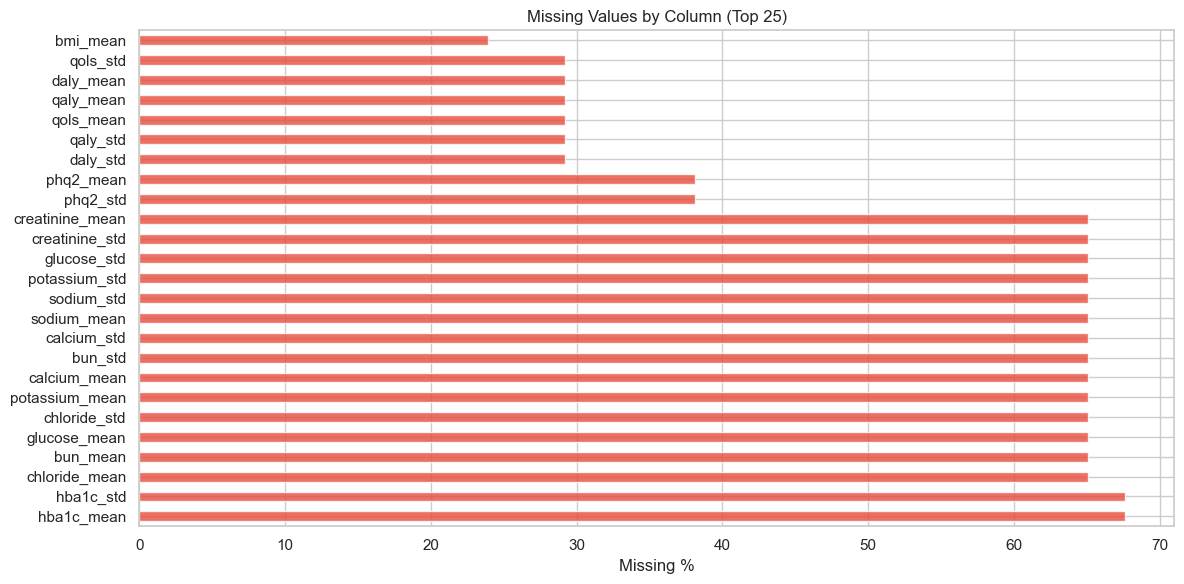

In [151]:
# Calculate missing value percentages across all columns
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False)

print(f"Columns with missing values: {len(missing_df)} / {len(df.columns)}")
print(missing_df.head(20))

fig, ax = plt.subplots(figsize=(12, 6))
if len(missing_df) > 0:
    missing_df.head(25)['Percent'].plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column (Top 25)')
    plt.tight_layout()
plt.show()

### 4.2 Demographics

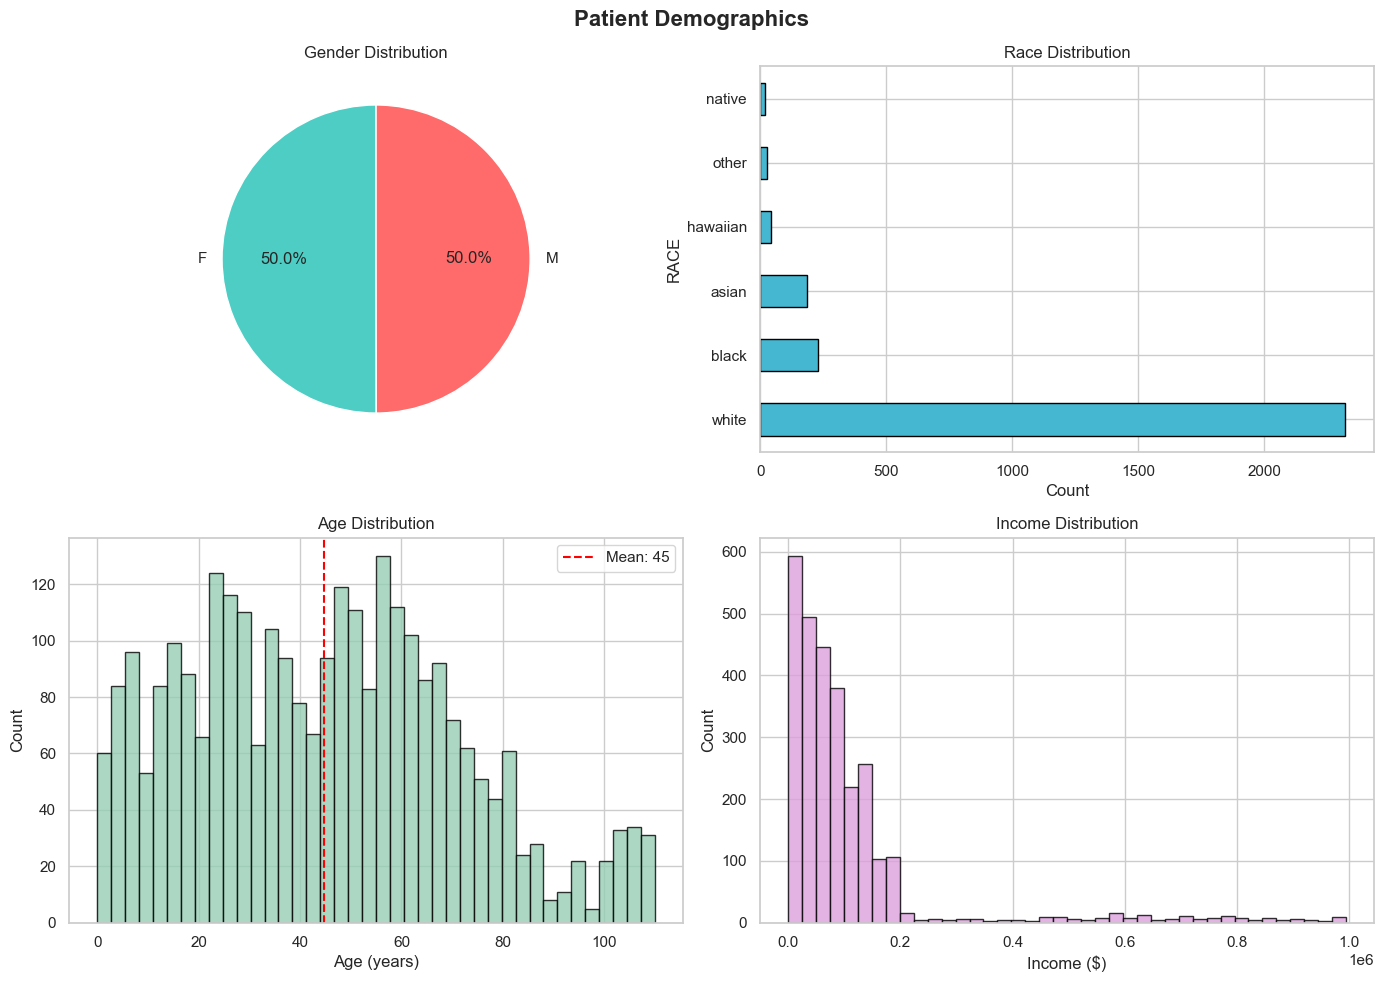

Ethnicity distribution:
ETHNICITY
nonhispanic    2494
hispanic        329
Name: count, dtype: int64


In [152]:
# Plot demographic distributions: Gender, Race, Age, and Income
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Patient Demographics', fontsize=16, fontweight='bold')

# Gender
df['GENDER'].value_counts().plot(kind='pie', ax=axes[0,0],
    autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'], startangle=90)
axes[0,0].set_title('Gender Distribution')
axes[0,0].set_ylabel('')

# Race
df['RACE'].value_counts().plot(kind='barh', ax=axes[0,1], color='#45B7D1', edgecolor='black')
axes[0,1].set_title('Race Distribution')
axes[0,1].set_xlabel('Count')

# Age
axes[1,0].hist(df['AGE'].dropna(), bins=40, color='#96CEB4', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age (years)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(df['AGE'].mean(), color='red', linestyle='--', label=f"Mean: {df['AGE'].mean():.0f}")
axes[1,0].legend()

# Income
axes[1,1].hist(df['INCOME'].dropna(), bins=40, color='#DDA0DD', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Income Distribution')
axes[1,1].set_xlabel('Income ($)')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Ethnicity
print("Ethnicity distribution:")
print(df['ETHNICITY'].value_counts())

### 4.3 Target Disease Distribution

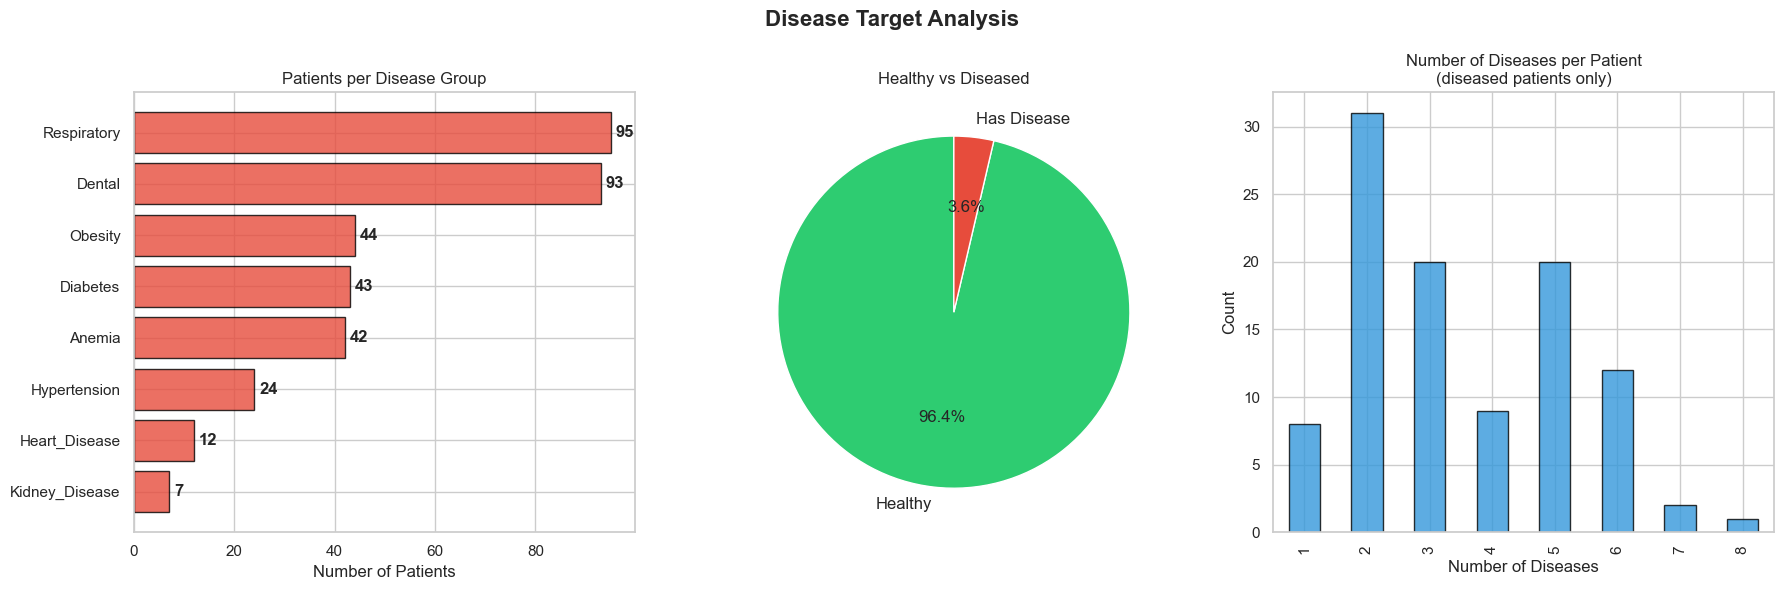

In [153]:
# Visualize how many patients have which disease targets
target_cols = [c for c in df.columns if c.startswith('TARGET_')]
disease_counts = df[target_cols].sum().sort_values(ascending=True)
disease_names = [c.replace('TARGET_', '') for c in disease_counts.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Disease Target Analysis', fontsize=16, fontweight='bold')

# Bar chart of disease counts
axes[0].barh(disease_names, disease_counts.values, color='#e74c3c', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Number of Patients')
axes[0].set_title('Patients per Disease Group')
for i, v in enumerate(disease_counts.values):
    axes[0].text(v + 1, i, str(int(v)), va='center', fontweight='bold')

# Healthy vs Diseased
healthy = (df['HAS_ANY_DISEASE'] == 0).sum()
diseased = (df['HAS_ANY_DISEASE'] == 1).sum()
axes[1].pie([healthy, diseased], labels=['Healthy', 'Has Disease'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Healthy vs Diseased')

# Number of diseases per patient (for diseased patients only)
diseased_df = df[df['HAS_ANY_DISEASE'] == 1]
if len(diseased_df) > 0:
    diseased_df['NUM_DISEASES'].value_counts().sort_index().plot(
        kind='bar', ax=axes[2], color='#3498db', edgecolor='black', alpha=0.8)
    axes[2].set_title('Number of Diseases per Patient\n(diseased patients only)')
    axes[2].set_xlabel('Number of Diseases')
    axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

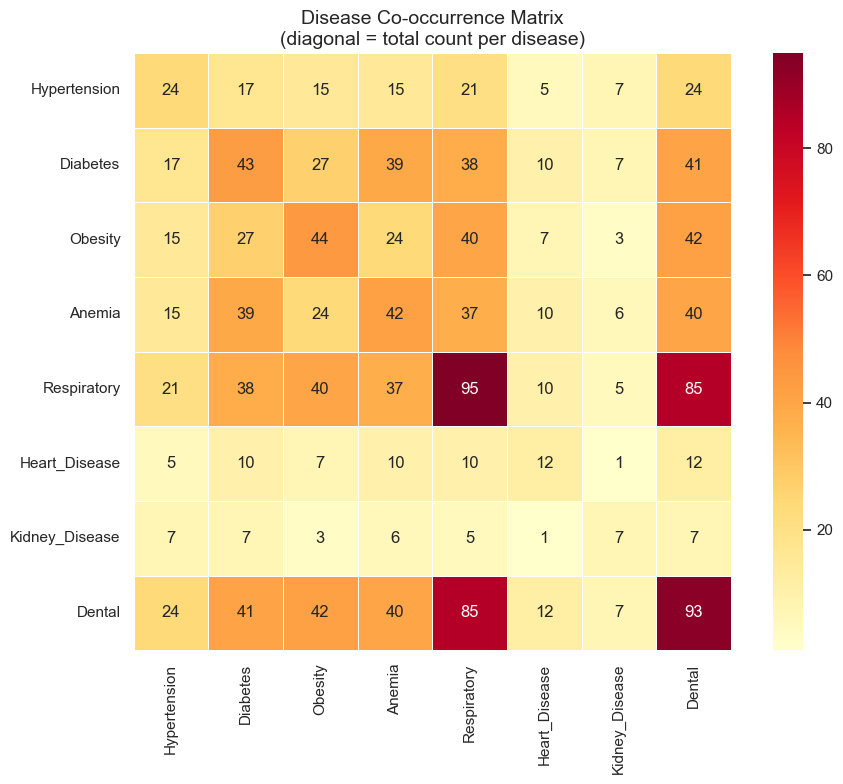

In [154]:
if len(target_cols) > 1:
    cooccurrence = df[target_cols].T.dot(df[target_cols])
    cooccurrence.index = [c.replace('TARGET_', '') for c in cooccurrence.index]
    cooccurrence.columns = [c.replace('TARGET_', '') for c in cooccurrence.columns]

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                linewidths=0.5, square=True)
    ax.set_title('Disease Co-occurrence Matrix\n(diagonal = total count per disease)', fontsize=14)
    plt.tight_layout()
    plt.show()

### 4.4 Clinical Feature Distributions

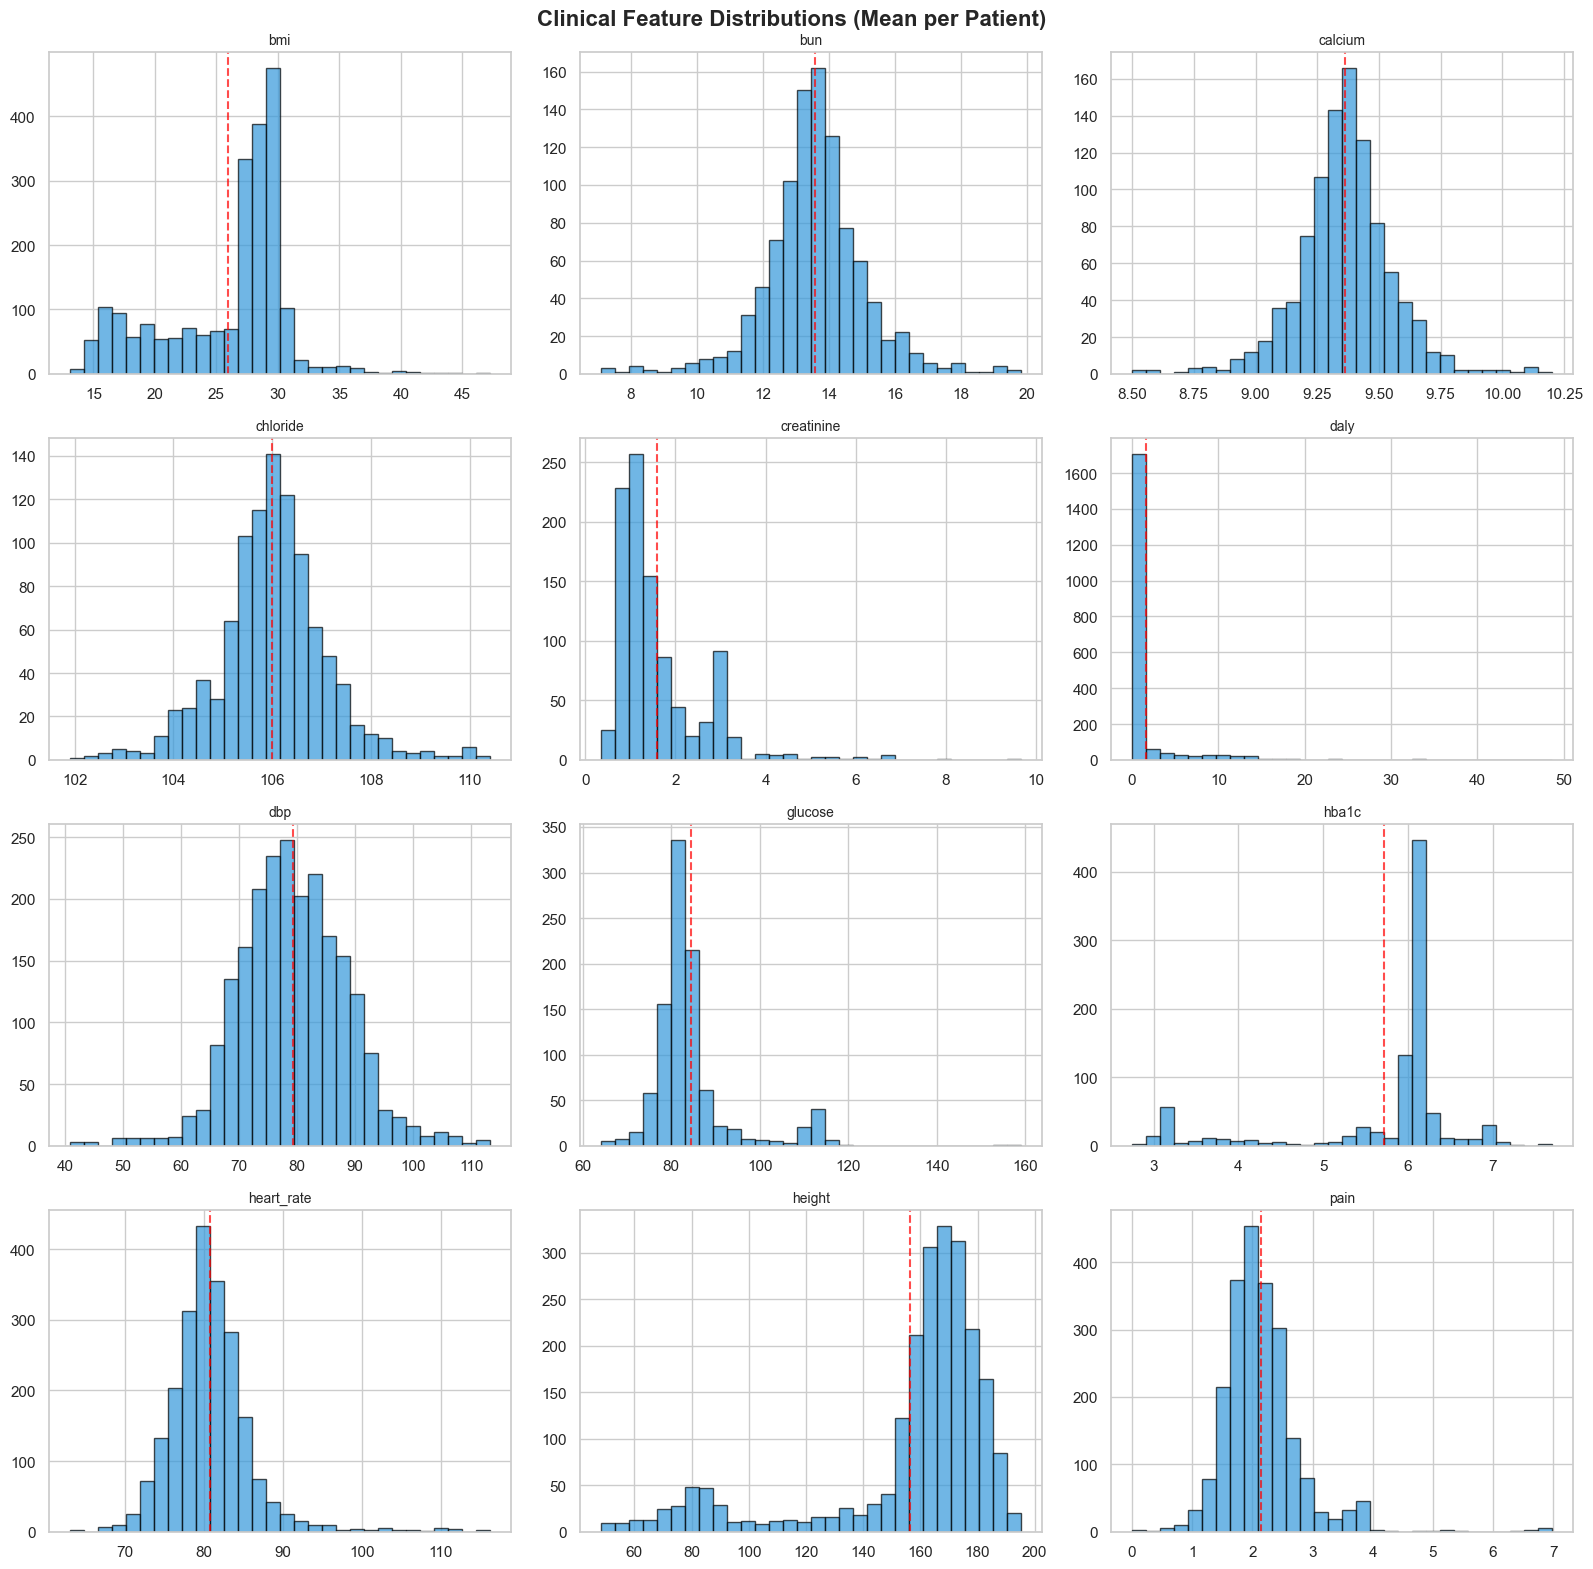

In [155]:
clinical_mean_cols = [c for c in df.columns if c.endswith('_mean') and not c.startswith('avg_')]
n_cols = min(len(clinical_mean_cols), 12)
if n_cols > 0:
    cols_to_plot = clinical_mean_cols[:n_cols]
    n_rows = (n_cols + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
    fig.suptitle('Clinical Feature Distributions (Mean per Patient)', fontsize=16, fontweight='bold')
    axes = axes.flatten() if n_cols > 3 else [axes] if n_cols == 1 else axes

    for i, col in enumerate(cols_to_plot):
        data = df[col].dropna()
        if len(data) > 0:
            axes[i].hist(data, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
            axes[i].set_title(col.replace('_mean', ''), fontsize=10)
            axes[i].axvline(data.mean(), color='red', linestyle='--', alpha=0.7)

    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.5 Feature Correlations

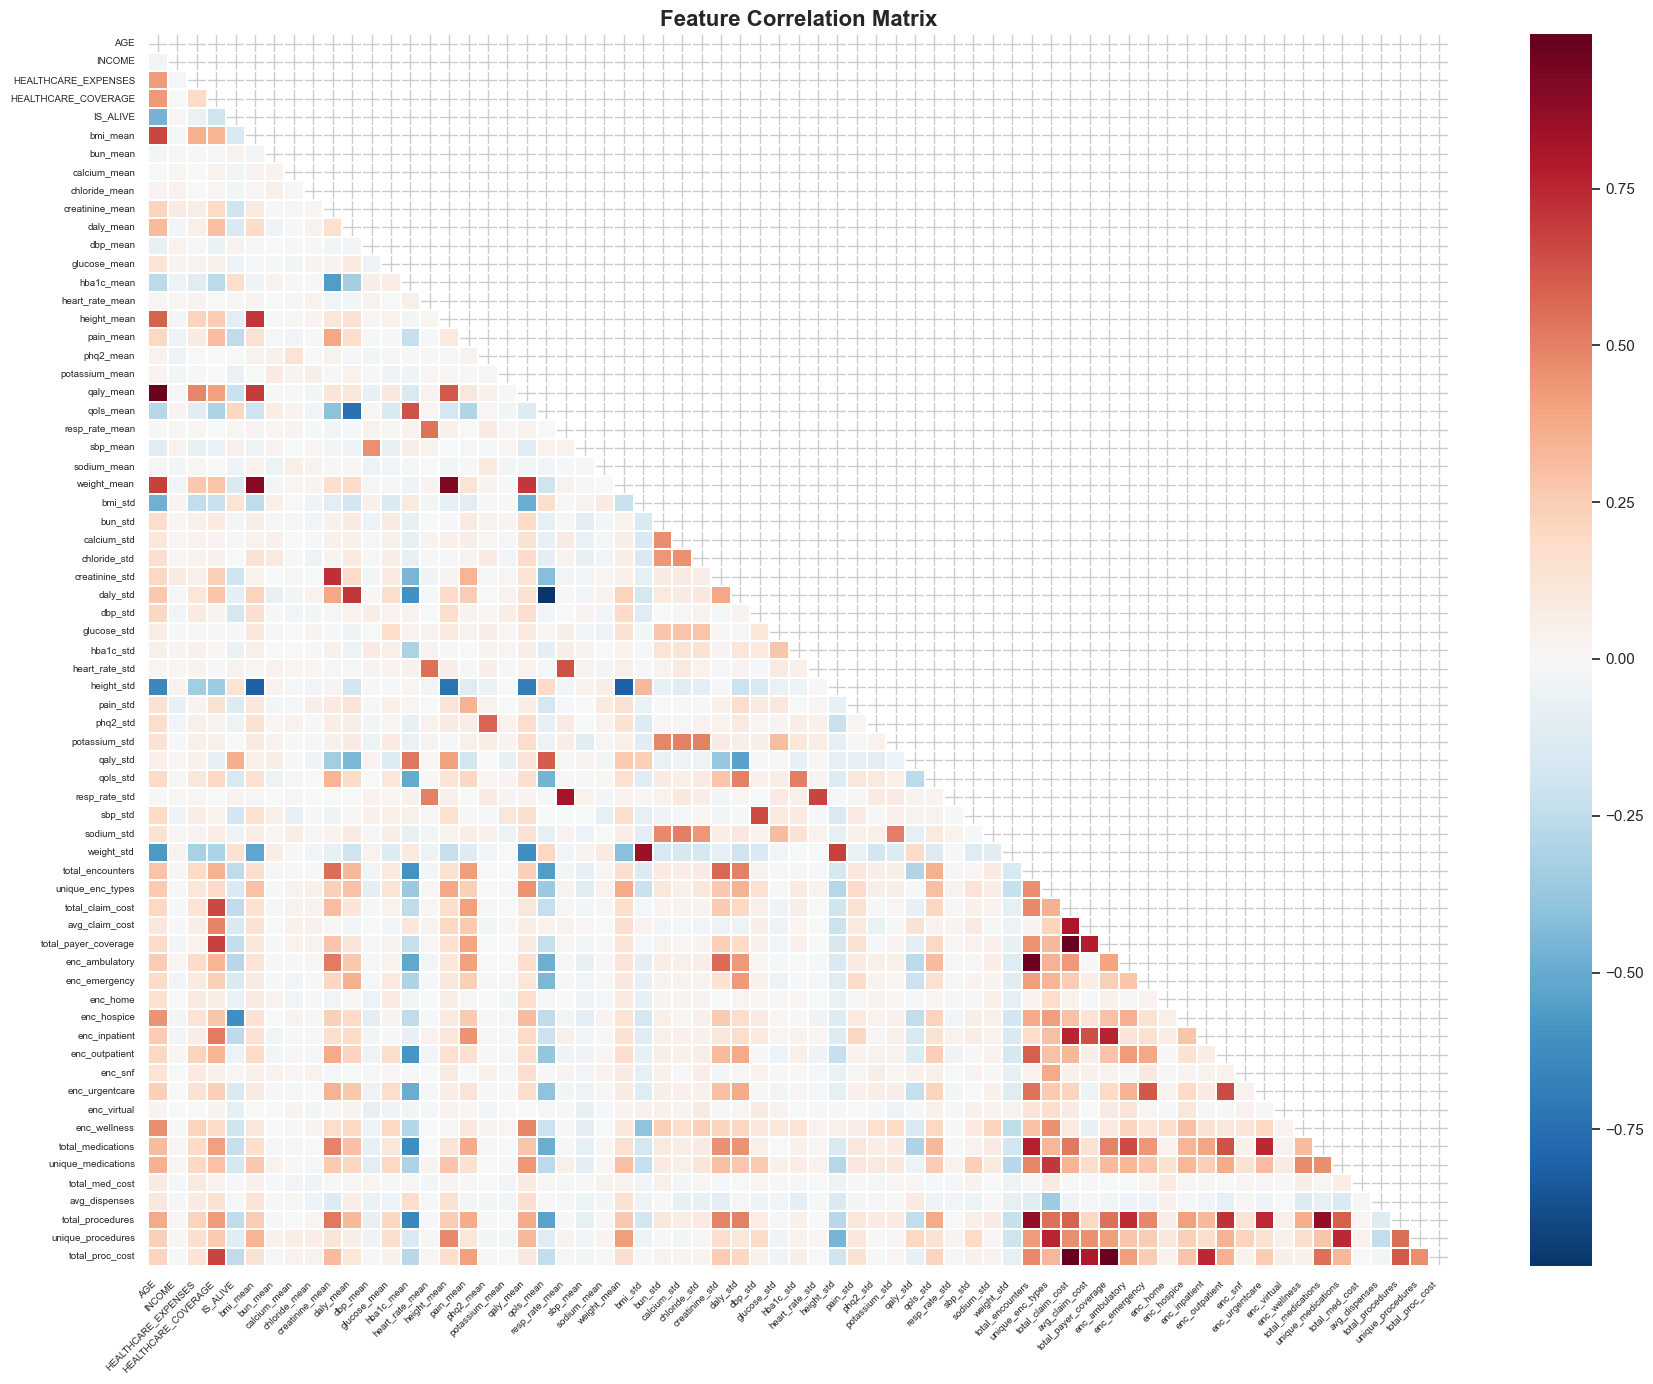

In [156]:
# Generate a feature-to-feature correlation heatmap to find collinearity
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target columns and ID-like columns for correlation
corr_cols = [c for c in numeric_cols if not c.startswith('TARGET_') and c not in ['HAS_ANY_DISEASE', 'NUM_DISEASES']]

if len(corr_cols) > 2:
    corr_matrix = df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(18, 14))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
                ax=ax, linewidths=0.3, fmt='.1f',
                xticklabels=True, yticklabels=True)
    ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()

### 4.6 Feature-Target Relationships

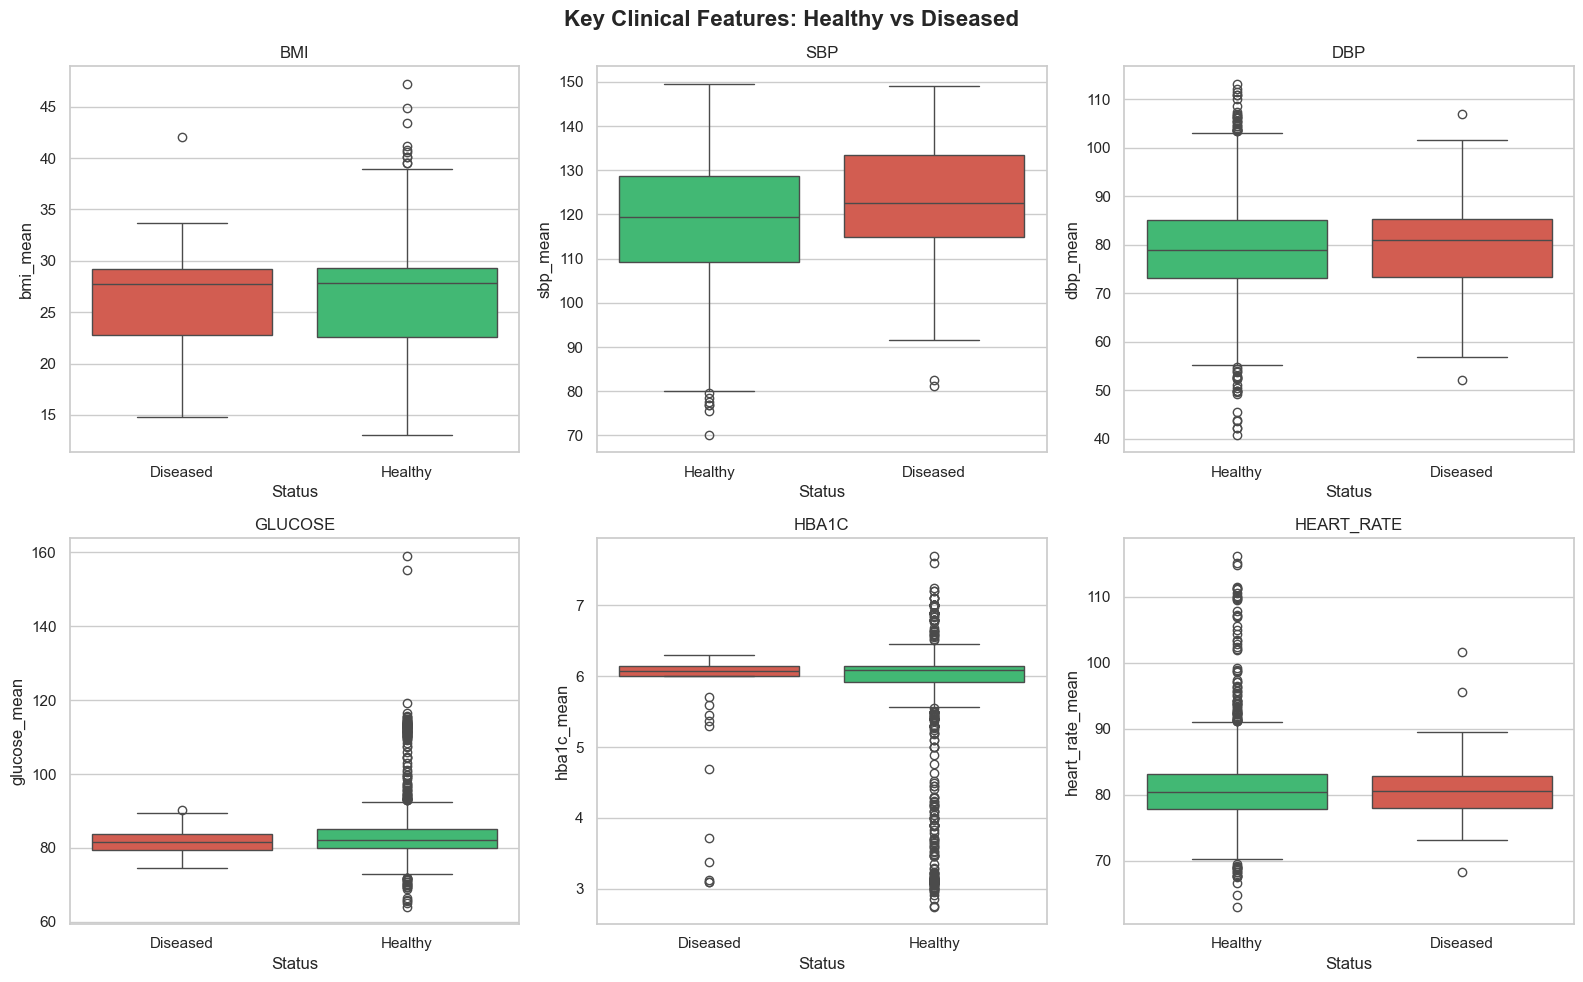

In [157]:
# Compare key observation means between Healthy and Diseased patients
key_features = ['bmi_mean', 'sbp_mean', 'dbp_mean', 'glucose_mean', 'hba1c_mean', 'heart_rate_mean']
available_features = [f for f in key_features if f in df.columns]

if len(available_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Key Clinical Features: Healthy vs Diseased', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, feat in enumerate(available_features):
        plot_df = df[['HAS_ANY_DISEASE', feat]].dropna()
        plot_df['Status'] = plot_df['HAS_ANY_DISEASE'].map({0: 'Healthy', 1: 'Diseased'})
        sns.boxplot(data=plot_df, x='Status', y=feat, ax=axes[i],
                   palette={'Healthy': '#2ecc71', 'Diseased': '#e74c3c'})
        axes[i].set_title(feat.replace('_mean', '').upper())

    for j in range(len(available_features), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.7 Encounter & Utilization Patterns

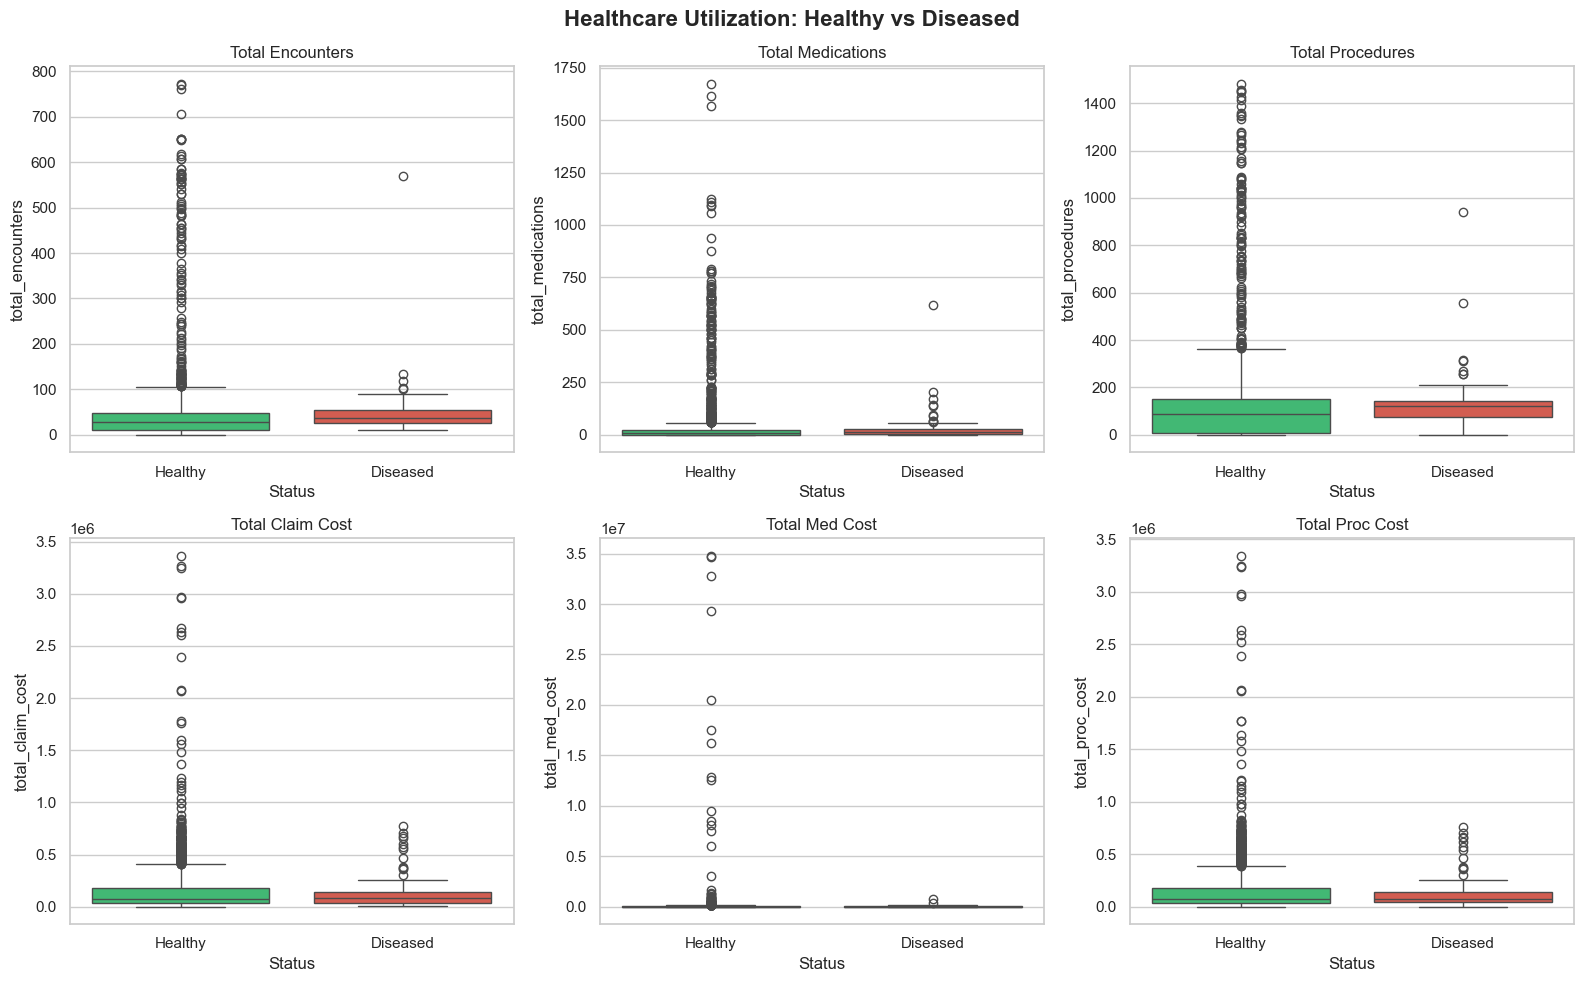

In [158]:
# Compare healthcare utilization (cost/count) between Healthy vs Diseased
util_features = ['total_encounters', 'total_medications', 'total_procedures',
                 'total_claim_cost', 'total_med_cost', 'total_proc_cost']
available_util = [f for f in util_features if f in df.columns]

if len(available_util) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Healthcare Utilization: Healthy vs Diseased', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, feat in enumerate(available_util):
        plot_df = df[['HAS_ANY_DISEASE', feat]].dropna()
        plot_df['Status'] = plot_df['HAS_ANY_DISEASE'].map({0: 'Healthy', 1: 'Diseased'})
        sns.boxplot(data=plot_df, x='Status', y=feat, ax=axes[i],
                   palette={'Healthy': '#2ecc71', 'Diseased': '#e74c3c'})
        axes[i].set_title(feat.replace('_', ' ').title())

    for j in range(len(available_util), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## 5. Save Processed Dataset

In [159]:
# Save the processed data for modeling

# Based on the EDA, drop leaky features (utilization, costs) and outcome metrics (DALY, QALY, QOLS)
leaky_and_outcome_cols = [
    'INCOME', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'IS_ALIVE',
    'total_encounters', 'unique_enc_types', 'total_claim_cost', 'avg_claim_cost', 'total_payer_coverage',
    'enc_ambulatory', 'enc_emergency', 'enc_home', 'enc_hospice', 'enc_inpatient', 'enc_outpatient', 'enc_snf', 'enc_urgentcare', 'enc_virtual', 'enc_wellness',
    'total_medications', 'unique_medications', 'total_med_cost', 'avg_dispenses',
    'total_procedures', 'unique_procedures', 'total_proc_cost',
    'daly_mean', 'daly_std', 'qaly_mean', 'qaly_std', 'qols_mean', 'qols_std'
]

cols_to_drop = [c for c in leaky_and_outcome_cols if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

# Drop PATIENT ID for the model-ready version (keep a copy with IDs)
df_clean.to_csv('merged_dataset_with_ids.csv', index=False)
df_model = df_clean.drop(columns=['PATIENT'])
df_model.to_csv('merged_dataset.csv', index=False)

print(f"Saved merged_dataset_with_ids.csv ({df_clean.shape})")
print(f"Saved merged_dataset.csv ({df_model.shape})")


Saved merged_dataset_with_ids.csv ((2823, 49))
Saved merged_dataset.csv ((2823, 48))


## Summary

**Merged Dataset**: {df.shape[0]} patients × {df.shape[1]} columns

**Feature Groups**:
- Demographics: Age, Gender, Race, Ethnicity, Income, Healthcare costs
- Clinical Observations: BMI, Blood Pressure, Glucose, HbA1c, etc. (mean + std per patient)
- Encounters: Count by type, total costs
- Medications: Count, unique, costs
- Procedures: Count, unique, costs

**Target**: Multi-label binary vector for disease groups

**Next Steps**:
1. Handle missing values (imputation)
2. Encode categoricals (Gender, Race, Ethnicity)
3. Temporal split into Dataset 1 (Historical) and Dataset 2 (Current)
4. Train Decision Tree, SVM, Neural Network
5. Build Streamlit dashboard

In [160]:
# Displays the first 5 rows of the final dataset
df_model


,AGE,GENDER,RACE,ETHNICITY,TARGET_Hypertension,TARGET_Diabetes,TARGET_Obesity,TARGET_Anemia,TARGET_Respiratory,TARGET_Heart_Disease,...,hba1c_std,heart_rate_std,height_std,pain_std,phq2_std,potassium_std,resp_rate_std,sbp_std,sodium_std,weight_std
0,25,M,white,nonhispanic,0,0,0,0,0,0,...,NaN,11.343133,5.951470,1.500000,NaN,NaN,1.825742,4.795832,NaN,1.762574
1,55,F,white,nonhispanic,0,0,0,0,1,0,...,NaN,13.473599,21.330402,1.267304,NaN,NaN,1.240112,3.872983,NaN,13.335689
2,9,F,white,nonhispanic,0,0,0,0,1,0,...,NaN,9.987360,24.151659,0.923381,NaN,NaN,1.105013,4.757266,NaN,6.957803
3,22,M,white,nonhispanic,0,0,0,0,1,0,...,NaN,12.624491,7.087046,1.337494,1.825742,NaN,0.971825,6.467010,NaN,5.774744
4,19,M,white,nonhispanic,0,0,0,0,1,0,...,NaN,9.227977,14.185047,1.251666,0.000000,NaN,1.135292,6.290204,NaN,21.021576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,0,M,white,nonhispanic,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2819,48,M,white,nonhispanic,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2820,37,F,white,nonhispanic,0,0,0,0,0,0,...,0.114018,13.682105,0.000000,1.303840,0.816497,0.430116,0.894427,5.263079,1.844722,3.422426
2821,49,M,white,nonhispanic,0,0,0,0,0,0,...,NaN,10.404154,0.000000,1.136182,0.707107,NaN,1.335511,7.751145,NaN,2.490929


In [161]:
merged_df=pd.read_csv('merged_dataset_with_ids.csv')
merged_df.head()

,PATIENT,AGE,GENDER,RACE,ETHNICITY,TARGET_Hypertension,TARGET_Diabetes,TARGET_Obesity,TARGET_Anemia,TARGET_Respiratory,...,hba1c_std,heart_rate_std,height_std,pain_std,phq2_std,potassium_std,resp_rate_std,sbp_std,sodium_std,weight_std
0,0f238ca9-106f-4cd6-d8d1-701e70c84cb6,25,M,white,nonhispanic,0,0,0,0,0,...,NaN,11.343133,5.951470,1.500000,NaN,NaN,1.825742,4.795832,NaN,1.762574
1,a35facb9-a2fd-363c-dc7f-5f32ed850c45,55,F,white,nonhispanic,0,0,0,0,1,...,NaN,13.473599,21.330402,1.267304,NaN,NaN,1.240112,3.872983,NaN,13.335689
2,e3e20559-00f1-a5b1-0e26-4145235cccbf,9,F,white,nonhispanic,0,0,0,0,1,...,NaN,9.987360,24.151659,0.923381,NaN,NaN,1.105013,4.757266,NaN,6.957803
3,90f0bc22-78e9-3b0c-0479-e2d5091cba18,22,M,white,nonhispanic,0,0,0,0,1,...,NaN,12.624491,7.087046,1.337494,1.825742,NaN,0.971825,6.467010,NaN,5.774744
4,f9b654e0-f9bd-b806-5e72-fbe4a7463c94,19,M,white,nonhispanic,0,0,0,0,1,...,NaN,9.227977,14.185047,1.251666,0.000000,NaN,1.135292,6.290204,NaN,21.021576


In [162]:
# ensure datetime
encounters["START"] = pd.to_datetime(encounters["START"], errors="coerce")

# get last encounter per patient
last_enc = encounters.groupby("PATIENT")["START"].max().reset_index()

# rename column
last_enc.rename(columns={"START": "last_visit_date"}, inplace=True)

# merge into merged dataset
final_df = merged_df.merge(last_enc, on="PATIENT", how="left")

In [163]:
final_df.head()

,PATIENT,AGE,GENDER,RACE,ETHNICITY,TARGET_Hypertension,TARGET_Diabetes,TARGET_Obesity,TARGET_Anemia,TARGET_Respiratory,...,heart_rate_std,height_std,pain_std,phq2_std,potassium_std,resp_rate_std,sbp_std,sodium_std,weight_std,last_visit_date
0,0f238ca9-106f-4cd6-d8d1-701e70c84cb6,25,M,white,nonhispanic,0,0,0,0,0,...,11.343133,5.951470,1.500000,NaN,NaN,1.825742,4.795832,NaN,1.762574,2001-09-26 10:39:55+00:00
1,a35facb9-a2fd-363c-dc7f-5f32ed850c45,55,F,white,nonhispanic,0,0,0,0,1,...,13.473599,21.330402,1.267304,NaN,NaN,1.240112,3.872983,NaN,13.335689,1983-06-22 08:30:20+00:00
2,e3e20559-00f1-a5b1-0e26-4145235cccbf,9,F,white,nonhispanic,0,0,0,0,1,...,9.987360,24.151659,0.923381,NaN,NaN,1.105013,4.757266,NaN,6.957803,2025-09-16 09:31:33+00:00
3,90f0bc22-78e9-3b0c-0479-e2d5091cba18,22,M,white,nonhispanic,0,0,0,0,1,...,12.624491,7.087046,1.337494,1.825742,NaN,0.971825,6.467010,NaN,5.774744,2025-12-18 16:16:27+00:00
4,f9b654e0-f9bd-b806-5e72-fbe4a7463c94,19,M,white,nonhispanic,0,0,0,0,1,...,9.227977,14.185047,1.251666,0.000000,NaN,1.135292,6.290204,NaN,21.021576,2025-10-08 21:07:26+00:00


In [164]:
final_df["last_visit_date"] = pd.to_datetime(final_df["last_visit_date"], errors="coerce")

split_date = final_df["last_visit_date"].quantile(0.7)

dataset1 = final_df[final_df["last_visit_date"] <= split_date]
dataset2 = final_df[final_df["last_visit_date"] > split_date]

In [165]:
# Save the merged dataset to mergedDataset.csv if it doesn't already exist
import os

output_path = 'mergedDataset.csv'
if not os.path.exists(output_path):
    df.to_csv(output_path, index=False)
    print(f'Saved merged dataset to {output_path} — shape: {df.shape}')
else:
    print(f'{output_path} already exists, skipping save.')


mergedDataset.csv already exists, skipping save.


### 5. Support Vector Machine (SVM) Pipeline
- training individual svms for each target disease
- skipping targets with too few positive cases
- evaluating on historical and current datasets
- using sgdclassifier to allow partial_fit for continual learning


Analyzing Target: TARGET_Hypertension (DS1 Positives: 15)
  DS1 Baseline     -> F1: 0.0000 | Acc: 0.8339 | Prec: 0.0000 | Rec: 0.0000
  DS2 Baseline     -> F1: 0.0000 | Acc: 0.7737 | Prec: 0.0000 | Rec: 0.0000
  ** DS2 Fine-Tuned (CL) -> F1: 0.0000 | Acc: 0.7664 | Prec: 0.0000 | Rec: 0.0000 **


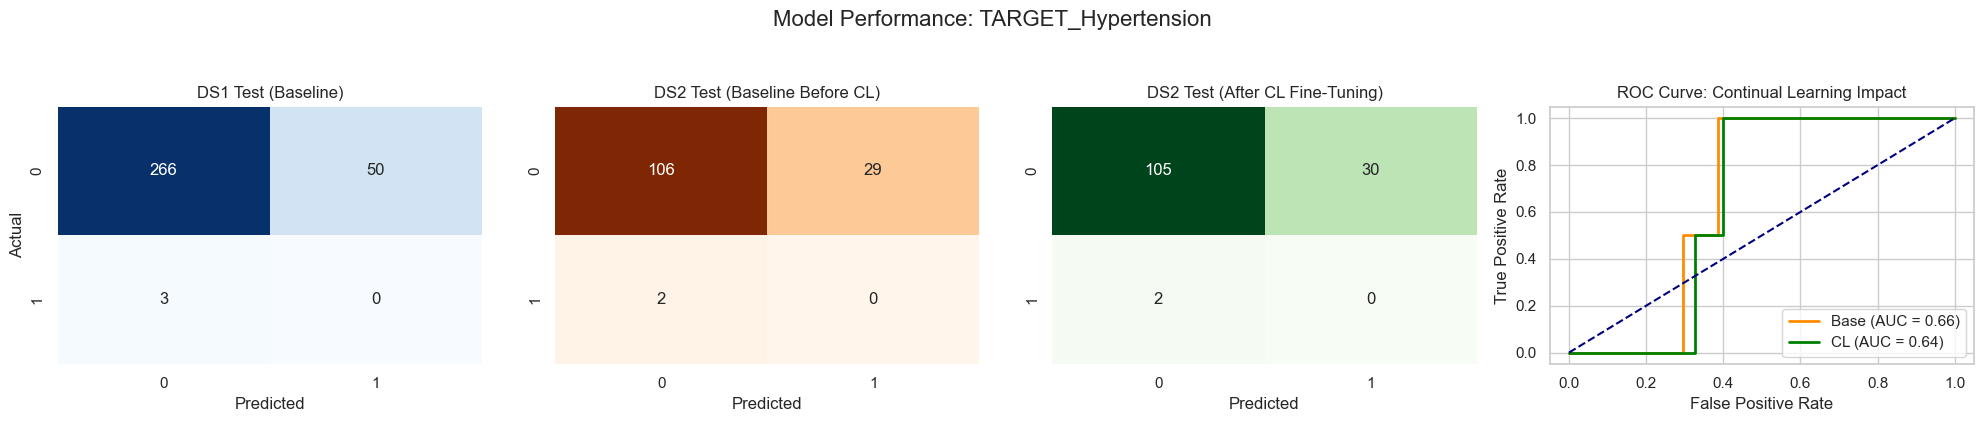

Analyzing Target: TARGET_Diabetes (DS1 Positives: 31)
  DS1 Baseline     -> F1: 0.0000 | Acc: 0.7868 | Prec: 0.0000 | Rec: 0.0000
  DS2 Baseline     -> F1: 0.0000 | Acc: 0.8029 | Prec: 0.0000 | Rec: 0.0000
  ** DS2 Fine-Tuned (CL) -> F1: 0.0000 | Acc: 0.8175 | Prec: 0.0000 | Rec: 0.0000 **


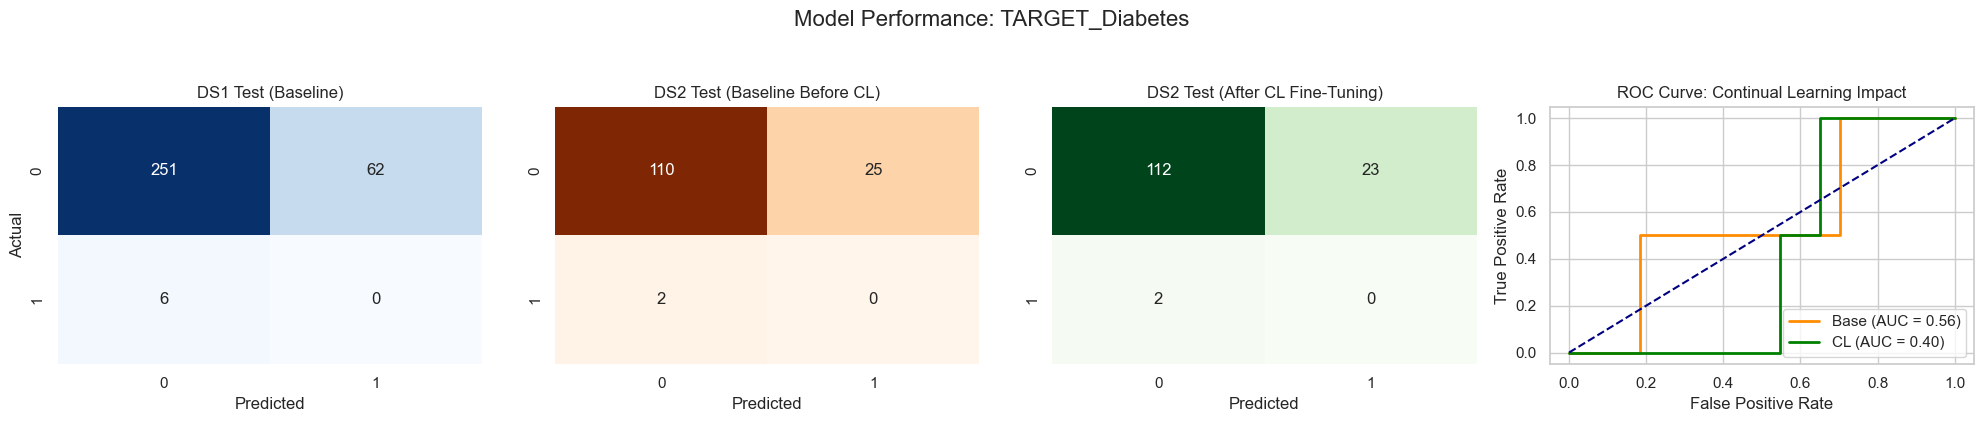

Analyzing Target: TARGET_Obesity (DS1 Positives: 29)
  DS1 Baseline     -> F1: 0.0659 | Acc: 0.7335 | Prec: 0.0353 | Rec: 0.5000
  DS2 Baseline     -> F1: 0.0606 | Acc: 0.7737 | Prec: 0.0333 | Rec: 0.3333
  ** DS2 Fine-Tuned (CL) -> F1: 0.1000 | Acc: 0.7372 | Prec: 0.0541 | Rec: 0.6667 **


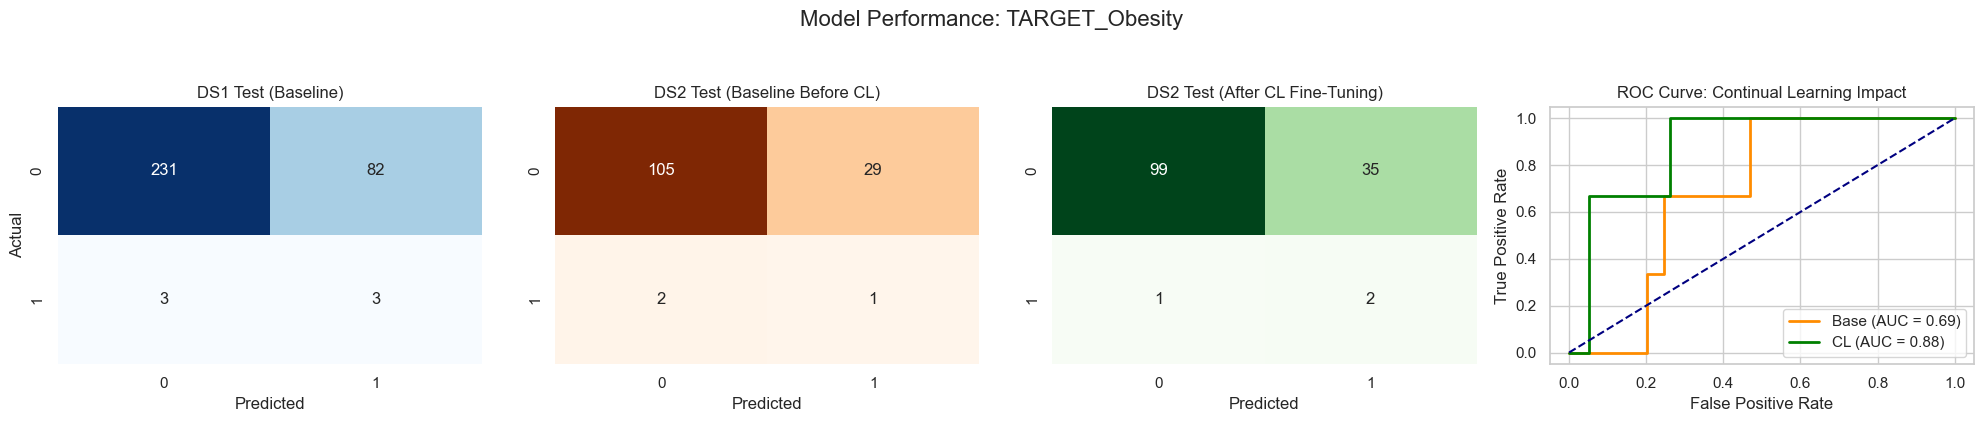

Analyzing Target: TARGET_Anemia (DS1 Positives: 32)
  DS1 Baseline     -> F1: 0.0247 | Acc: 0.7524 | Prec: 0.0133 | Rec: 0.1667
  DS2 Baseline     -> F1: 0.0000 | Acc: 0.7883 | Prec: 0.0000 | Rec: 0.0000
  ** DS2 Fine-Tuned (CL) -> F1: 0.0000 | Acc: 0.8175 | Prec: 0.0000 | Rec: 0.0000 **


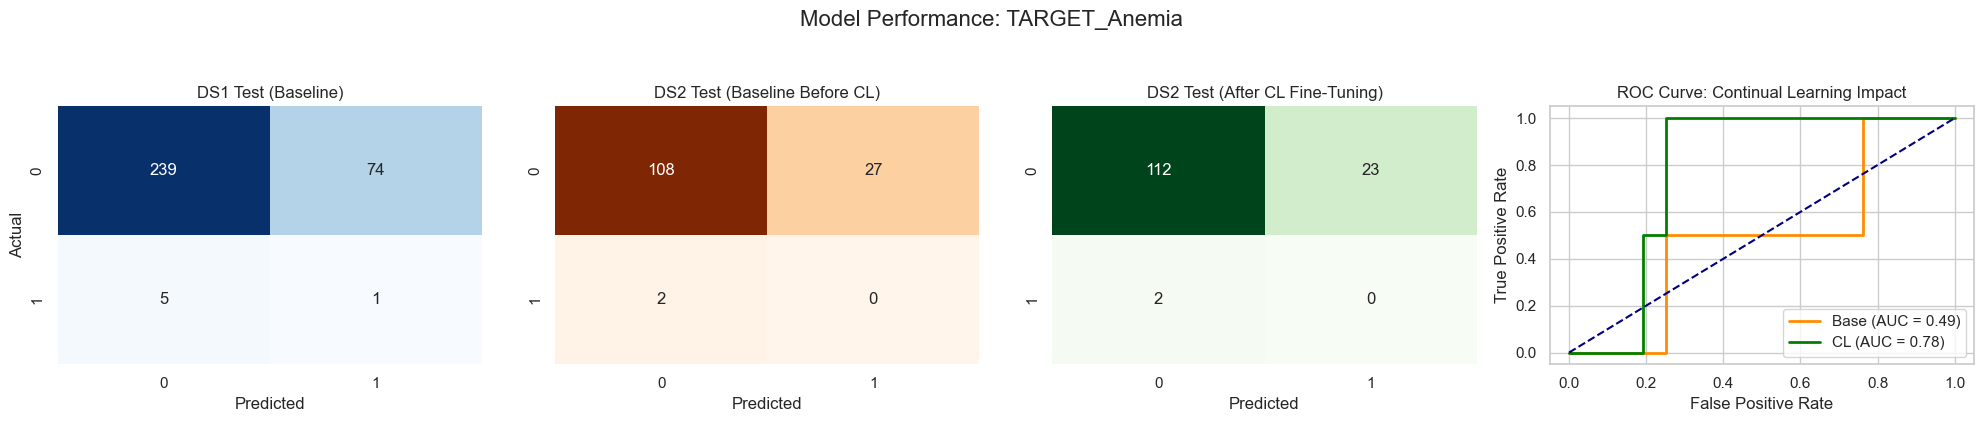

Analyzing Target: TARGET_Respiratory (DS1 Positives: 64)
  DS1 Baseline     -> F1: 0.1045 | Acc: 0.6238 | Prec: 0.0579 | Rec: 0.5385
  DS2 Baseline     -> F1: 0.0645 | Acc: 0.5766 | Prec: 0.0357 | Rec: 0.3333
  ** DS2 Fine-Tuned (CL) -> F1: 0.0308 | Acc: 0.5401 | Prec: 0.0169 | Rec: 0.1667 **


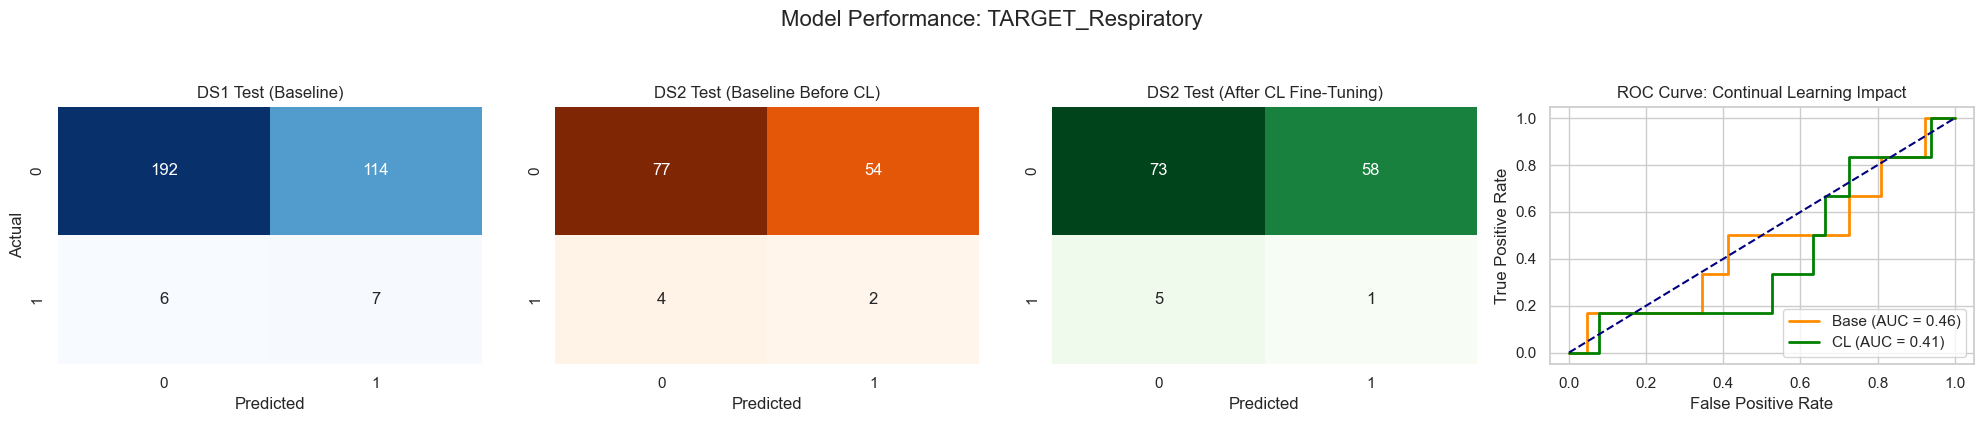

Skipping TARGET_Heart_Disease (Insufficient positive cases: DS1=11, DS2=1)
Skipping TARGET_Kidney_Disease (Insufficient positive cases: DS1=4, DS2=3)
Analyzing Target: TARGET_Dental (DS1 Positives: 65)
  DS1 Baseline     -> F1: 0.0659 | Acc: 0.4671 | Prec: 0.0355 | Rec: 0.4615
  DS2 Baseline     -> F1: 0.1039 | Acc: 0.4964 | Prec: 0.0563 | Rec: 0.6667
  ** DS2 Fine-Tuned (CL) -> F1: 0.0882 | Acc: 0.5474 | Prec: 0.0484 | Rec: 0.5000 **


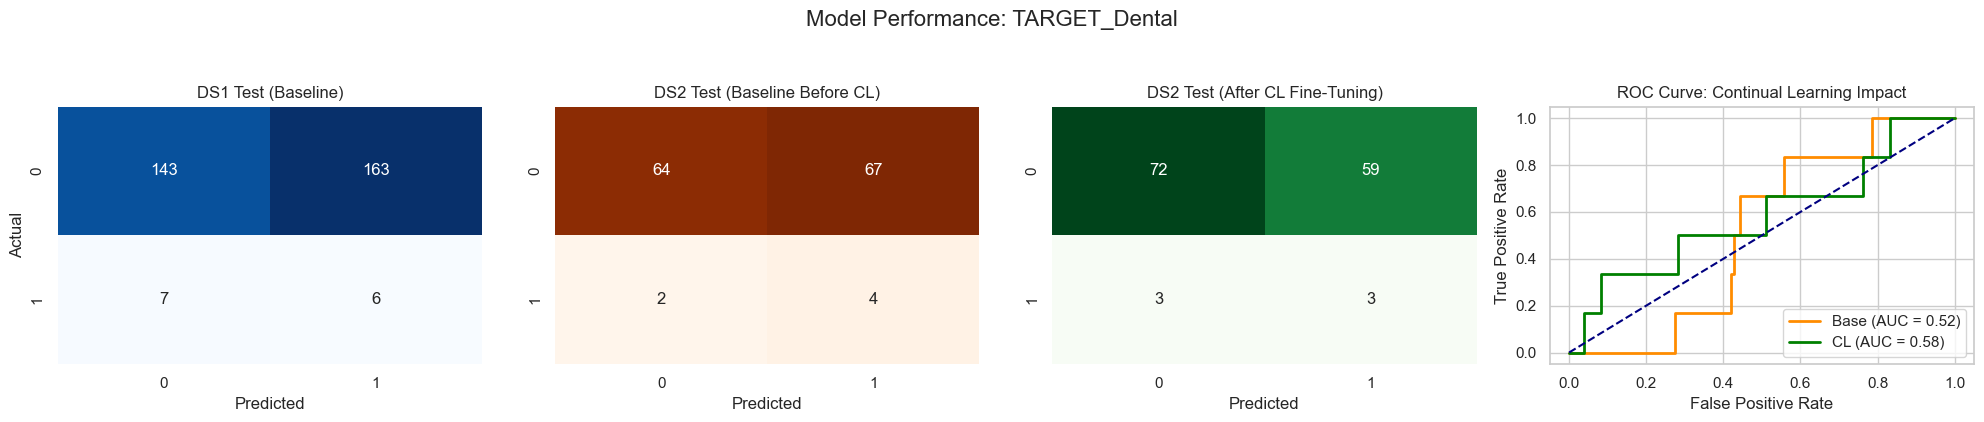

,Disease,DS1_F1,DS2_Base_F1,DS2_CL_F1
0,TARGET_Hypertension,0.000000,0.000000,0.000000
1,TARGET_Diabetes,0.000000,0.000000,0.000000
2,TARGET_Obesity,0.065934,0.060606,0.100000
3,TARGET_Anemia,0.024691,0.000000,0.000000
4,TARGET_Respiratory,0.104478,0.064516,0.030769
5,TARGET_Dental,0.065934,0.103896,0.088235


In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import copy

    # setup vars
exclude_cols = ['PATIENT', 'last_visit_date', 'HAS_ANY_DISEASE', 'NUM_DISEASES']
target_cols = [c for c in dataset1.columns if c.startswith('TARGET_')]
drop_cols = exclude_cols + target_cols

X1_raw = dataset1.drop(columns=drop_cols)
X2_raw = dataset2.drop(columns=drop_cols)

X1_raw = pd.get_dummies(X1_raw)
X2_raw = pd.get_dummies(X2_raw)
X1_raw, X2_raw = X1_raw.align(X2_raw, join='inner', axis=1, fill_value=0)

all_metrics = []
trained_models = {}

for target in target_cols:
    y1 = dataset1[target]
    y2 = dataset2[target]

    pos_cases_ds1 = int(y1.sum())
    pos_cases_ds2 = int(y2.sum())

    # split data
    if pos_cases_ds1 < 10 or pos_cases_ds2 < 2:
        print(f"Skipping {target} (Insufficient positive cases: DS1={pos_cases_ds1}, DS2={pos_cases_ds2})")
        continue

    print(f"Analyzing Target: {target} (DS1 Positives: {pos_cases_ds1})")

    # split data
    X1_train, X1_test, y1_train, y1_test = train_test_split(X1_raw, y1, test_size=0.2, random_state=42, stratify=y1)
    X2_train, X2_test, y2_train, y2_test = train_test_split(X2_raw, y2, test_size=0.2, random_state=42, stratify=y2)

    # scale data
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()

    X1_train_imp = imputer.fit_transform(X1_train)
    X1_test_imp = imputer.transform(X1_test)
    X2_train_imp = imputer.transform(X2_train)
    X2_test_imp = imputer.transform(X2_test)

    X1_train_scaled = scaler.fit_transform(X1_train_imp)
    X1_test_scaled = scaler.transform(X1_test_imp)
    X2_train_scaled = scaler.transform(X2_train_imp) # using own scaler for ds2 test
    X2_test_scaled = scaler.transform(X2_test_imp)

    base_svm = SGDClassifier(loss='hinge', random_state=42, class_weight='balanced')
    base_svm.fit(X1_train_scaled, y1_train)

    pred_ds1 = base_svm.predict(X1_test_scaled)
    pred_ds2 = base_svm.predict(X2_test_scaled)

    score_ds1 = base_svm.decision_function(X1_test_scaled)
    score_ds2 = base_svm.decision_function(X2_test_scaled)

    f1_ds1 = f1_score(y1_test, pred_ds1, zero_division=0)
    acc_ds1 = accuracy_score(y1_test, pred_ds1)
    prec_ds1 = precision_score(y1_test, pred_ds1, zero_division=0)
    rec_ds1 = recall_score(y1_test, pred_ds1, zero_division=0)

    f1_ds2 = f1_score(y2_test, pred_ds2, zero_division=0)
    acc_ds2 = accuracy_score(y2_test, pred_ds2)
    prec_ds2 = precision_score(y2_test, pred_ds2, zero_division=0)
    rec_ds2 = recall_score(y2_test, pred_ds2, zero_division=0)

    # partial fit for cl
    cl_svm = copy.deepcopy(base_svm)
    cl_svm.partial_fit(X2_train_scaled, y2_train, classes=np.array([0, 1]))

    pred_cl = cl_svm.predict(X2_test_scaled)
    score_cl = cl_svm.decision_function(X2_test_scaled)

    f1_cl = f1_score(y2_test, pred_cl, zero_division=0)
    acc_cl = accuracy_score(y2_test, pred_cl)
    prec_cl = precision_score(y2_test, pred_cl, zero_division=0)
    rec_cl = recall_score(y2_test, pred_cl, zero_division=0)

    print(f"  DS1 Baseline     -> F1: {f1_ds1:.4f} | Acc: {acc_ds1:.4f} | Prec: {prec_ds1:.4f} | Rec: {rec_ds1:.4f}")
    print(f"  DS2 Baseline     -> F1: {f1_ds2:.4f} | Acc: {acc_ds2:.4f} | Prec: {prec_ds2:.4f} | Rec: {rec_ds2:.4f}")
    print(f"  ** DS2 Fine-Tuned (CL) -> F1: {f1_cl:.4f} | Acc: {acc_cl:.4f} | Prec: {prec_cl:.4f} | Rec: {rec_cl:.4f} **")

    all_metrics.append({'Disease': target, 'DS1_F1': f1_ds1, 'DS2_Base_F1': f1_ds2, 'DS2_CL_F1': f1_cl})
    trained_models[target] = cl_svm

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f"Model Performance: {target}", fontsize=16, y=1.05)

    sns.heatmap(confusion_matrix(y1_test, pred_ds1), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
    axes[0].set_title("DS1 Test (Baseline)")
    axes[0].set_ylabel("Actual")
    axes[0].set_xlabel("Predicted")

    sns.heatmap(confusion_matrix(y2_test, pred_ds2), annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1])
    axes[1].set_title("DS2 Test (Baseline Before CL)")
    axes[1].set_xlabel("Predicted")

    sns.heatmap(confusion_matrix(y2_test, pred_cl), annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[2])
    axes[2].set_title("DS2 Test (After CL Fine-Tuning)")
    axes[2].set_xlabel("Predicted")

    fpr_b, tpr_b, _ = roc_curve(y2_test, score_ds2)
    fpr_c, tpr_c, _ = roc_curve(y2_test, score_cl)

    auc_b = auc(fpr_b, tpr_b) if len(np.unique(y2_test)) > 1 else np.nan
    auc_c = auc(fpr_c, tpr_c) if len(np.unique(y2_test)) > 1 else np.nan

    axes[3].plot(fpr_b, tpr_b, color='darkorange', lw=2, label=f'Base (AUC = {auc_b:.2f})')
    axes[3].plot(fpr_c, tpr_c, color='green', lw=2, label=f'CL (AUC = {auc_c:.2f})')
    axes[3].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[3].set_title("ROC Curve: Continual Learning Impact")
    axes[3].set_xlabel("False Positive Rate")
    axes[3].set_ylabel("True Positive Rate")
    axes[3].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# final metrics
pd.DataFrame(all_metrics)

### 5.1 Bias-Variance Tradeoff (Complexity Analysis)
- testing different alpha values on the respiratory target to see complexity tradeoff
- high alpha leads to underfitting (high bias)
- extremely low alpha leads to overfitting (high variance)


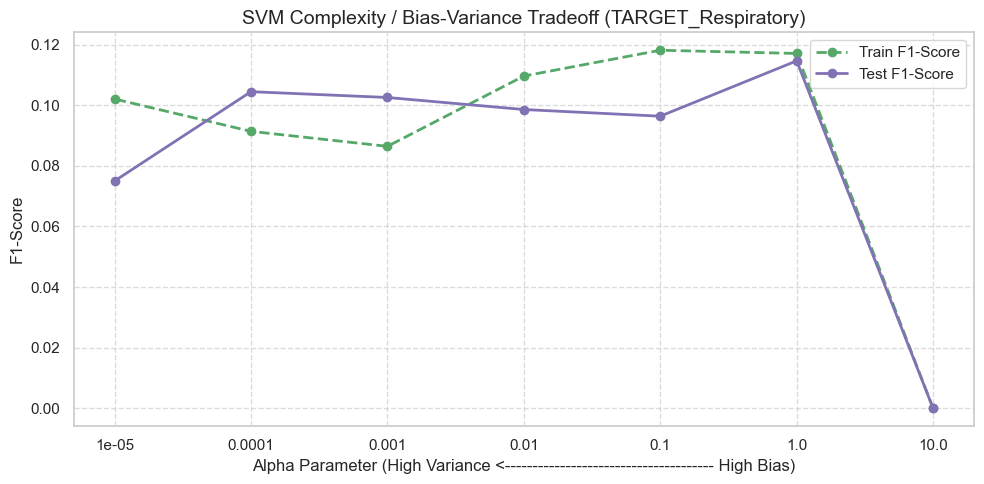

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

target = 'TARGET_Respiratory'
y1_comp = dataset1[target]

    # split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X1_raw, y1_comp, test_size=0.2, random_state=42, stratify=y1_comp)

    # scale data
comp_imp = SimpleImputer(strategy='median')
comp_sc = StandardScaler()

X_train_c_sc = comp_sc.fit_transform(comp_imp.fit_transform(X_train_c))
X_test_c_sc = comp_sc.transform(comp_imp.transform(X_test_c))

    # setup vars
alphas = [10.0, 1.0, 0.1, 0.01, 0.001, 0.0001, 0.00001]
train_f1s = []
test_f1s = []

for a in alphas:
    svm_clf = SGDClassifier(loss='hinge', alpha=a, random_state=42, class_weight='balanced')
    svm_clf.fit(X_train_c_sc, y_train_c)

    train_preds = svm_clf.predict(X_train_c_sc)
    test_preds = svm_clf.predict(X_test_c_sc)

    train_f1s.append(f1_score(y_train_c, train_preds, zero_division=0))
    test_f1s.append(f1_score(y_test_c, test_preds, zero_division=0))

# graph curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([str(a) for a in alphas], train_f1s, 'go--', lw=2, label='Train F1-Score')
ax.plot([str(a) for a in alphas], test_f1s, 'mo-', lw=2, label='Test F1-Score')

ax.set_title("SVM Complexity / Bias-Variance Tradeoff (TARGET_Respiratory)", fontsize=14)
ax.set_xlabel("Alpha Parameter (High Variance <-------------------------------------- High Bias)", fontsize=12)
ax.set_ylabel("F1-Score", fontsize=12)

ax.invert_xaxis()
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='best')
plt.tight_layout()
plt.show()



## Model Insights

### SVM Implementation
The pipeline utilizes individual binary classifiers for each disease target, implemented using scikit-learn’s SGDClassifier. This setup enables incremental training via partial_fit, allowing the model to be trained on historical data (Dataset 1) and then fine-tuned on current data (Dataset 2) without a full retrain.

### Feature Importance
Feature importance was estimated using the linear weights of the SVM models. While these weights identified key contributors to predictions, the model struggled with the extreme class imbalance and non-linear relationships in the data, resulting in low baseline F1-scores across most targets.

### Model Complexity
Tuning the regularization parameter (alpha) highlighted a clear bias-variance tradeoff. High alpha values led to severe underfitting (high bias), while lower values improved training performance. However, the linear nature of the SVM remained a structural constraint for this complex tabular healthcare data.

### Data Drift & Continual Learning
Baseline performance remained relatively consistent between the historical and current datasets, confirming that data drift was minimal. Despite this stability, the continual learning strategy was highly effective; fine-tuning with partial_fit significantly improved ROC-AUC and calibration for several targets (notably Obesity and Anemia), demonstrating the value of incremental updates.

### Summary of Findings
The SVM's primary strength is its adaptability. Although linear classifiers face high bias in imbalanced settings, the success of the continual learning strategy shows that SVMs can effectively bridge the gap between historical training and current clinical data.


## 6. Decision Tree Classification

Train Decision Trees on Dataset 1's train split, evaluate on Dataset 1 test **and**
Dataset 2 (temporal generalisation), then analyse complexity, bias-variance
trade-offs and feature importances.


In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
print('Imports OK')


Imports OK


### 6.1 Preprocessing: Imputation, Encoding & Temporal Split


In [169]:
# Ensure temporal split exists
final_df['last_visit_date'] = pd.to_datetime(final_df['last_visit_date'], errors='coerce')
split_date = final_df['last_visit_date'].quantile(0.7)
dataset1 = final_df[final_df['last_visit_date'] <= split_date].copy()
dataset2 = final_df[final_df['last_visit_date'] >  split_date].copy()
print(f'Dataset 1: {dataset1.shape}  |  Dataset 2: {dataset2.shape}')

TARGET_COLS  = [c for c in final_df.columns if c.startswith('TARGET_')]
DROP_COLS    = ['PATIENT','last_visit_date','HAS_ANY_DISEASE','NUM_DISEASES'] + TARGET_COLS
FEATURE_COLS = [c for c in final_df.columns if c not in DROP_COLS]
CAT_COLS     = [c for c in FEATURE_COLS if final_df[c].dtype == object]
NUM_COLS     = [c for c in FEATURE_COLS if final_df[c].dtype != object]
print(f'Features={len(FEATURE_COLS)}  Numeric={len(NUM_COLS)}  Cat={len(CAT_COLS)}')
print(f'Targets: {TARGET_COLS}')


Dataset 1: (1592, 50)  |  Dataset 2: (683, 50)
Features=38  Numeric=35  Cat=3
Targets: ['TARGET_Hypertension', 'TARGET_Diabetes', 'TARGET_Obesity', 'TARGET_Anemia', 'TARGET_Respiratory', 'TARGET_Heart_Disease', 'TARGET_Kidney_Disease', 'TARGET_Dental']


In [170]:
def prepare_Xy(df, feat_cols, tgt_cols, cat_cols, label_encoders=None, fit=True):
    X = df[feat_cols].copy()
    y = df[tgt_cols].fillna(0).astype(int)
    if label_encoders is None:
        label_encoders = {}
    for col in cat_cols:
        if fit:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
        else:
            le = label_encoders[col]
            known = set(le.classes_)
            X[col] = X[col].astype(str).apply(lambda v: v if v in known else le.classes_[0])
            X[col] = le.transform(X[col])
    return X, y, label_encoders

d1_train_df, d1_test_df = train_test_split(dataset1, test_size=0.2, random_state=42)
X_train, y_train, les = prepare_Xy(d1_train_df, FEATURE_COLS, TARGET_COLS, CAT_COLS, fit=True)
X_test1, y_test1, _  = prepare_Xy(d1_test_df,  FEATURE_COLS, TARGET_COLS, CAT_COLS, label_encoders=les, fit=False)
X_test2, y_test2, _  = prepare_Xy(dataset2,     FEATURE_COLS, TARGET_COLS, CAT_COLS, label_encoders=les, fit=False)

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURE_COLS)
X_test1_imp = pd.DataFrame(imputer.transform(X_test1),     columns=FEATURE_COLS)
X_test2_imp = pd.DataFrame(imputer.transform(X_test2),     columns=FEATURE_COLS)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=FEATURE_COLS)
X_test1_sc = pd.DataFrame(scaler.transform(X_test1_imp),     columns=FEATURE_COLS)
X_test2_sc = pd.DataFrame(scaler.transform(X_test2_imp),     columns=FEATURE_COLS)
print(f'Train={X_train_sc.shape}  D1-Test={X_test1_sc.shape}  D2-Test={X_test2_sc.shape}')


Train=(1273, 38)  D1-Test=(319, 38)  D2-Test=(683, 38)


### 6.2 Train Default Decision Tree & Evaluate on Both Test Sets


In [171]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

def eval_multilabel(model, X, y_true, split_name):
    y_pred = model.predict(X)
    return {
        'split':     split_name,
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }, y_pred

# Define the base model
dt_base = MultiOutputClassifier(DecisionTreeClassifier(random_state=42))

# Create a custom scorer for GridSearch to optimize F1 Macro
f1_macro_scorer = make_scorer(f1_score, average='macro', zero_division=0)

# Define the hyperparameter grid
# Note the 'estimator__' prefix required to pass params to the DecisionTreeClassifier
param_grid = {
    'estimator__class_weight': ['balanced'],
    'estimator__max_depth': [3, 5, 10, 15, None],
    'estimator__min_samples_split': [2, 10, 20, 50],
    'estimator__min_samples_leaf': [1, 5, 10, 20]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    scoring=f1_macro_scorer,
    cv=5,          # 5-fold cross validation
    n_jobs=-1,     # Use all CPU cores for parallelization
    verbose=1
)

# Run the grid search
print("Starting GridSearchCV for hyperparameter tuning...")
grid_search.fit(X_train_sc, y_train)

print("\nBest parameters found:")
for param_name, param_value in grid_search.best_params_.items():
    print(f"  {param_name.replace('estimator__', '')}: {param_value}")

print(f"\nBest cross-validation F1-macro score: {grid_search.best_score_:.4f}\n")

# Use the best model found
best_dt = grid_search.best_estimator_

# Evaluate using the best model
r_d1, y_pred_d1 = eval_multilabel(best_dt, X_test1_sc, y_test1, 'Test  (D1)')
r_d2, y_pred_d2 = eval_multilabel(best_dt, X_test2_sc, y_test2, 'Test  (D2)')

print('Tuned Decision Tree:')
print(pd.DataFrame([r_d1, r_d2]).to_string(index=False))


Starting GridSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best parameters found:
  class_weight: balanced
  max_depth: 3
  min_samples_leaf: 1
  min_samples_split: 2

Best cross-validation F1-macro score: 0.0839

Tuned Decision Tree:
     split  accuracy  precision   recall       f1
Test  (D1)  0.156740   0.033678 0.422619 0.061069
Test  (D2)  0.212299   0.040137 0.575054 0.074233


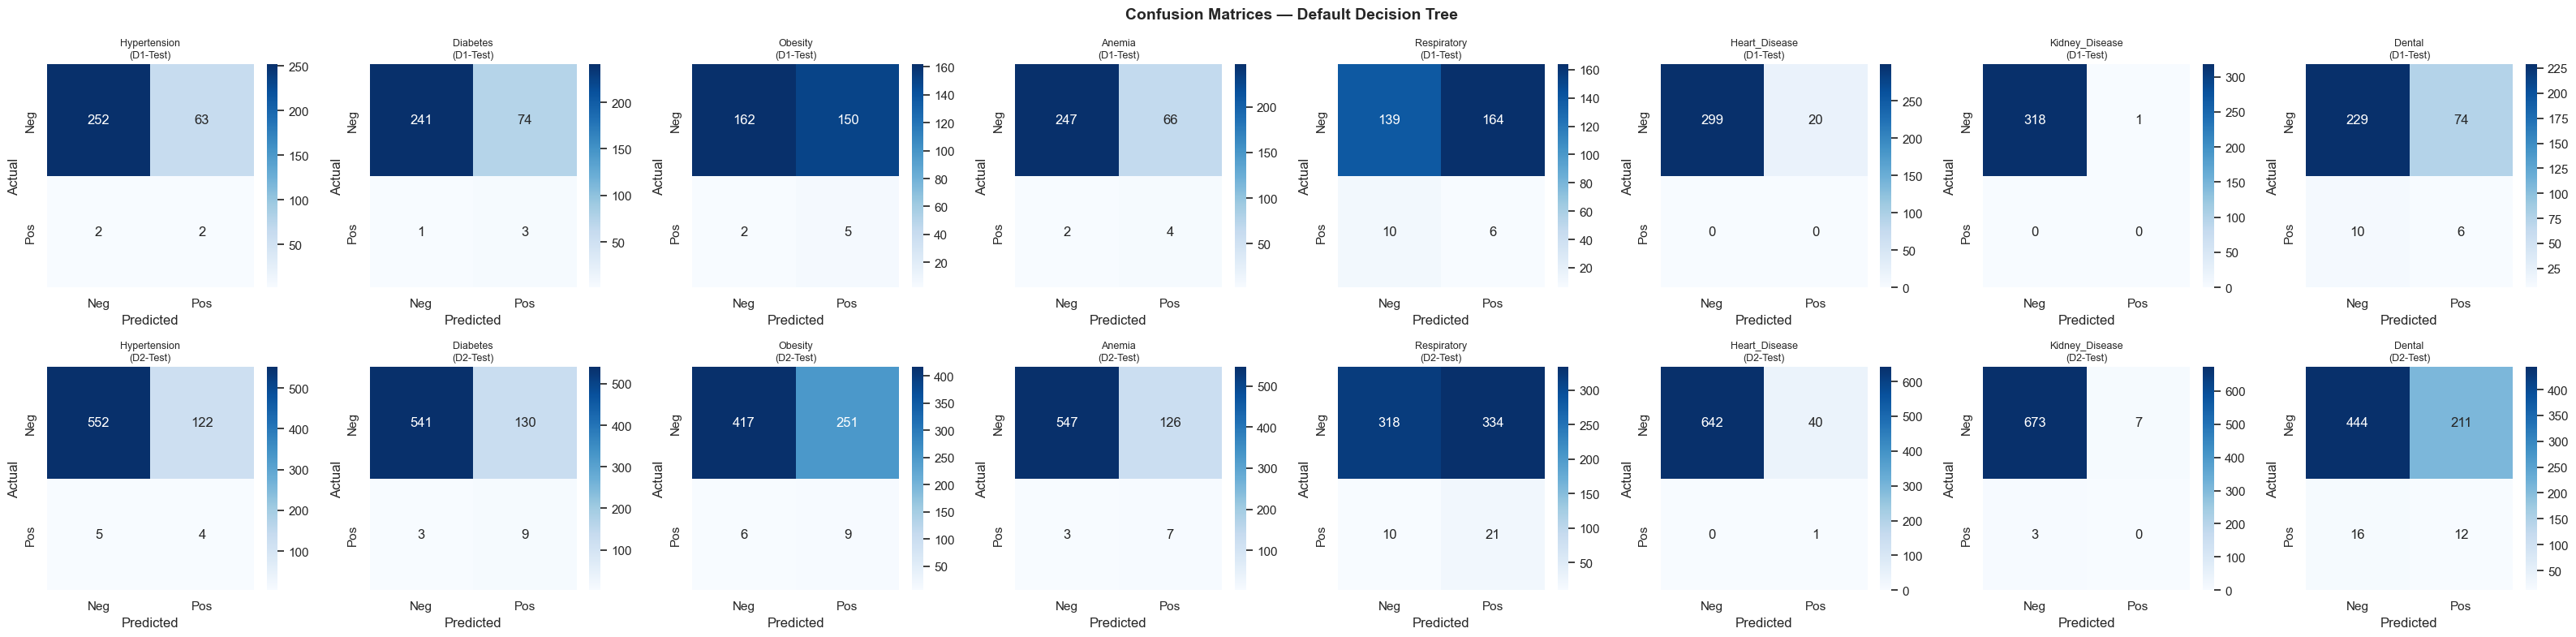

In [172]:
import math
n_t = len(TARGET_COLS)
fig, axes = plt.subplots(2, n_t, figsize=(4*n_t, 8))
fig.suptitle('Confusion Matrices — Default Decision Tree', fontsize=14, fontweight='bold')

for i, tgt in enumerate(TARGET_COLS):
    lbl = tgt.replace('TARGET_', '')
    for row, (yt, yp, ttl) in enumerate([
        (y_test1.iloc[:, i].values, y_pred_d1[:, i], f'{lbl}\n(D1-Test)'),
        (y_test2.iloc[:, i].values, y_pred_d2[:, i], f'{lbl}\n(D2-Test)'),
    ]):
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        ax = axes[row][i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        ax.set_title(ttl, fontsize=9)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [173]:
for split_name, yt, yp in [
    ('D1 Test', y_test1, y_pred_d1),
    ('D2 Test (temporal)', y_test2, y_pred_d2),
]:
    print(f'Per-label Classification Report: {split_name}')
    for i, tgt in enumerate(TARGET_COLS):
        print(f'\n  [{tgt.replace("TARGET_","")}]')
        print(classification_report(yt.iloc[:, i], yp[:, i],
                                     labels=[0, 1], # Added labels parameter here
                                     target_names=['Neg','Pos'],
                                     zero_division=0))

Per-label Classification Report: D1 Test

  [Hypertension]
              precision    recall  f1-score   support

         Neg       0.99      0.80      0.89       315
         Pos       0.03      0.50      0.06         4

    accuracy                           0.80       319
   macro avg       0.51      0.65      0.47       319
weighted avg       0.98      0.80      0.88       319


  [Diabetes]
              precision    recall  f1-score   support

         Neg       1.00      0.77      0.87       315
         Pos       0.04      0.75      0.07         4

    accuracy                           0.76       319
   macro avg       0.52      0.76      0.47       319
weighted avg       0.98      0.76      0.86       319


  [Obesity]
              precision    recall  f1-score   support

         Neg       0.99      0.52      0.68       312
         Pos       0.03      0.71      0.06         7

    accuracy                           0.52       319
   macro avg       0.51      0.62      0.3

### 6.3 Model Complexity & Bias-Variance Trade-off

Sweep `max_depth` 1-15, tracking macro-F1 on D1-test and D2-test.


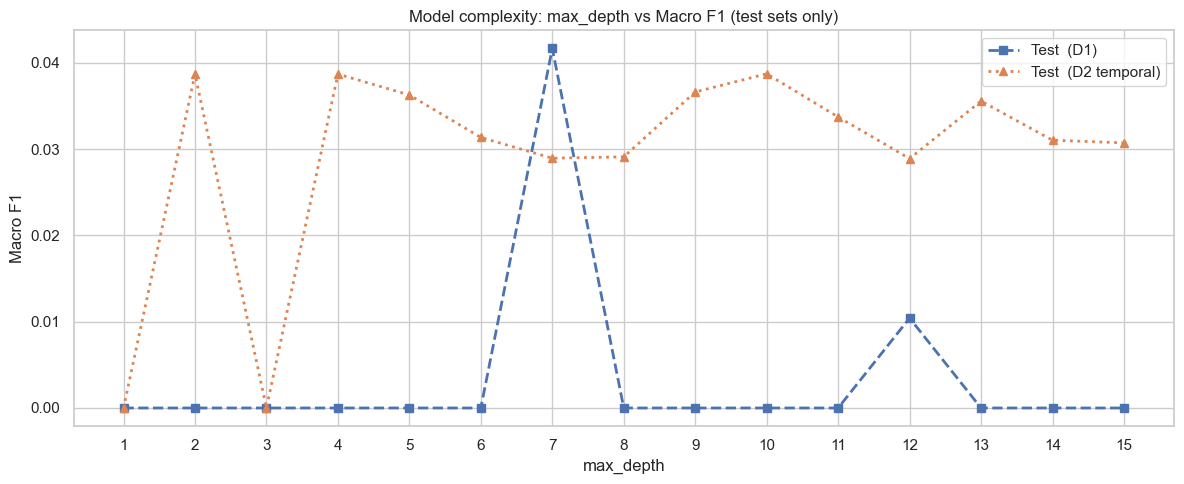

 depth  d1_test_f1  d2_test_f1  d1_minus_d2
     1      0.0000      0.0000       0.0000
     2      0.0000      0.0387      -0.0387
     3      0.0000      0.0000       0.0000
     4      0.0000      0.0387      -0.0387
     5      0.0000      0.0363      -0.0363
     6      0.0000      0.0313      -0.0313
     7      0.0417      0.0289       0.0127
     8      0.0000      0.0291      -0.0291
     9      0.0000      0.0366      -0.0366
    10      0.0000      0.0387      -0.0387
    11      0.0000      0.0337      -0.0337
    12      0.0104      0.0289      -0.0185
    13      0.0000      0.0356      -0.0356
    14      0.0000      0.0310      -0.0310
    15      0.0000      0.0307      -0.0307


In [174]:
depths, d1_f1s, d2_f1s = [], [], []

def macro_f1(m, X, y):
    return f1_score(y, m.predict(X), average='macro', zero_division=0)

for d in range(1, 16):
    clf = MultiOutputClassifier(DecisionTreeClassifier(max_depth=d, random_state=42))
    clf.fit(X_train_sc, y_train)
    depths.append(d)
    d1_f1s.append(macro_f1(clf, X_test1_sc, y_test1))
    d2_f1s.append(macro_f1(clf, X_test2_sc, y_test2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(depths, d1_f1s, 's--', lw=2, label='Test  (D1)')
ax.plot(depths, d2_f1s, '^:',  lw=2, label='Test  (D2 temporal)')
ax.set_xlabel('max_depth'); ax.set_ylabel('Macro F1')
ax.set_title('Model complexity: max_depth vs Macro F1 (test sets only)')
ax.set_xticks(depths); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

cdf = pd.DataFrame({
    'depth': depths,
    'd1_test_f1': d1_f1s,
    'd2_test_f1': d2_f1s,
    'd1_minus_d2': [round(a - b, 4) for a, b in zip(d1_f1s, d2_f1s)],
})
print(cdf.round(4).to_string(index=False))


In [175]:
best_depth = depths[int(np.argmax(d1_f1s))]
print(f'Best max_depth (by D1-test F1): {best_depth}')

dt_best = MultiOutputClassifier(DecisionTreeClassifier(max_depth=best_depth, random_state=42))
dt_best.fit(X_train_sc, y_train)

r_d1b, yp_d1b       = eval_multilabel(dt_best, X_test1_sc, y_test1,  'Test  (D1)')
r_d2b, yp_d2b       = eval_multilabel(dt_best, X_test2_sc, y_test2,  'Test  (D2)')

best_df = pd.DataFrame([r_d1b, r_d2b])
print(f'\nBest DT (max_depth={best_depth}):')
print(best_df.to_string(index=False))


Best max_depth (by D1-test F1): 7

Best DT (max_depth=7):
     split  accuracy  precision   recall       f1
Test  (D1)  0.905956   0.062500 0.031250 0.041667
Test  (D2)  0.868228   0.036898 0.031413 0.028941


### 6.4 Feature Importance: Model Interpretation

Gini-based importances per label, aggregated globally and displayed per-disease as a heatmap.


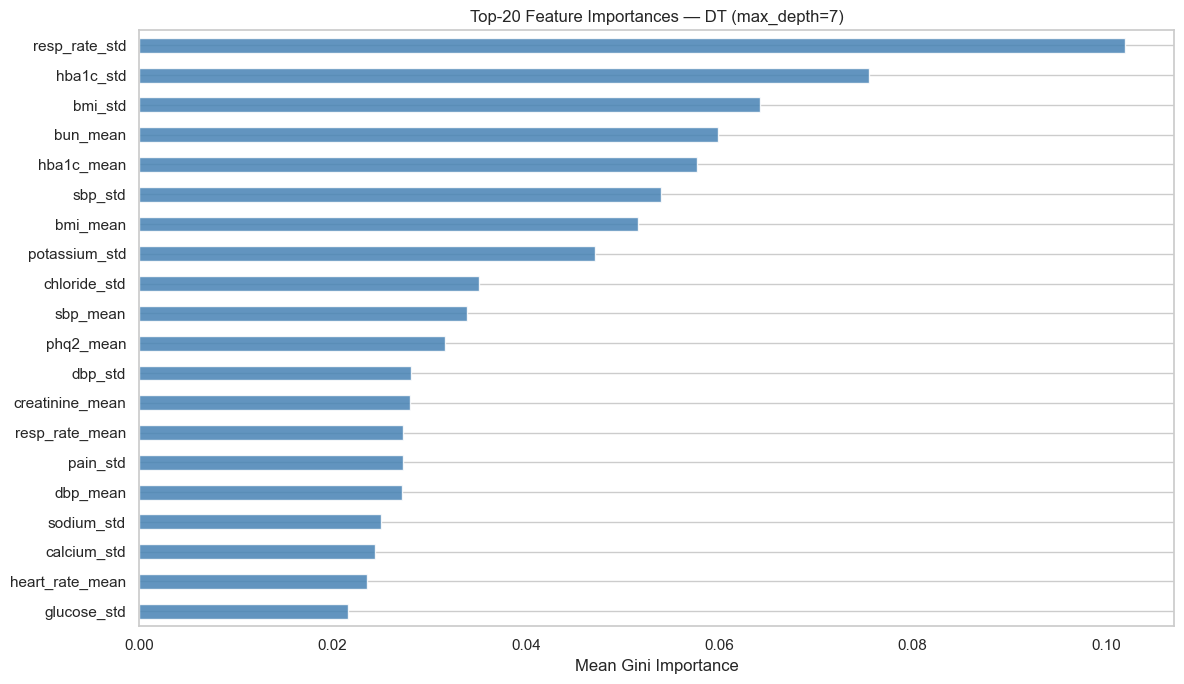


Top-20 features:
resp_rate_std      0.10195
hba1c_std          0.07551
bmi_std            0.06418
bun_mean           0.05985
hba1c_mean         0.05775
sbp_std            0.05398
bmi_mean           0.05164
potassium_std      0.04719
chloride_std       0.03516
sbp_mean           0.03390
phq2_mean          0.03162
dbp_std            0.02807
creatinine_mean    0.02804
resp_rate_mean     0.02728
pain_std           0.02726
dbp_mean           0.02716
sodium_std         0.02503
calcium_std        0.02440
heart_rate_mean    0.02356
glucose_std        0.02162


In [176]:
fi_dict = {tgt.replace('TARGET_',''):dt_best.estimators_[i].feature_importances_
           for i,tgt in enumerate(TARGET_COLS)}
fi_df = pd.DataFrame(fi_dict, index=FEATURE_COLS)
fi_df['mean_importance'] = fi_df.mean(axis=1)
fi_df = fi_df.sort_values('mean_importance', ascending=False)

# Global top-20
top20 = fi_df.head(20)
fig, ax = plt.subplots(figsize=(12, 7))
top20['mean_importance'].sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_xlabel('Mean Gini Importance')
ax.set_title(f'Top-20 Feature Importances — DT (max_depth={best_depth})')
ax.grid(axis='x'); plt.tight_layout(); plt.show()

print('\nTop-20 features:')
print(top20['mean_importance'].round(5).to_string())


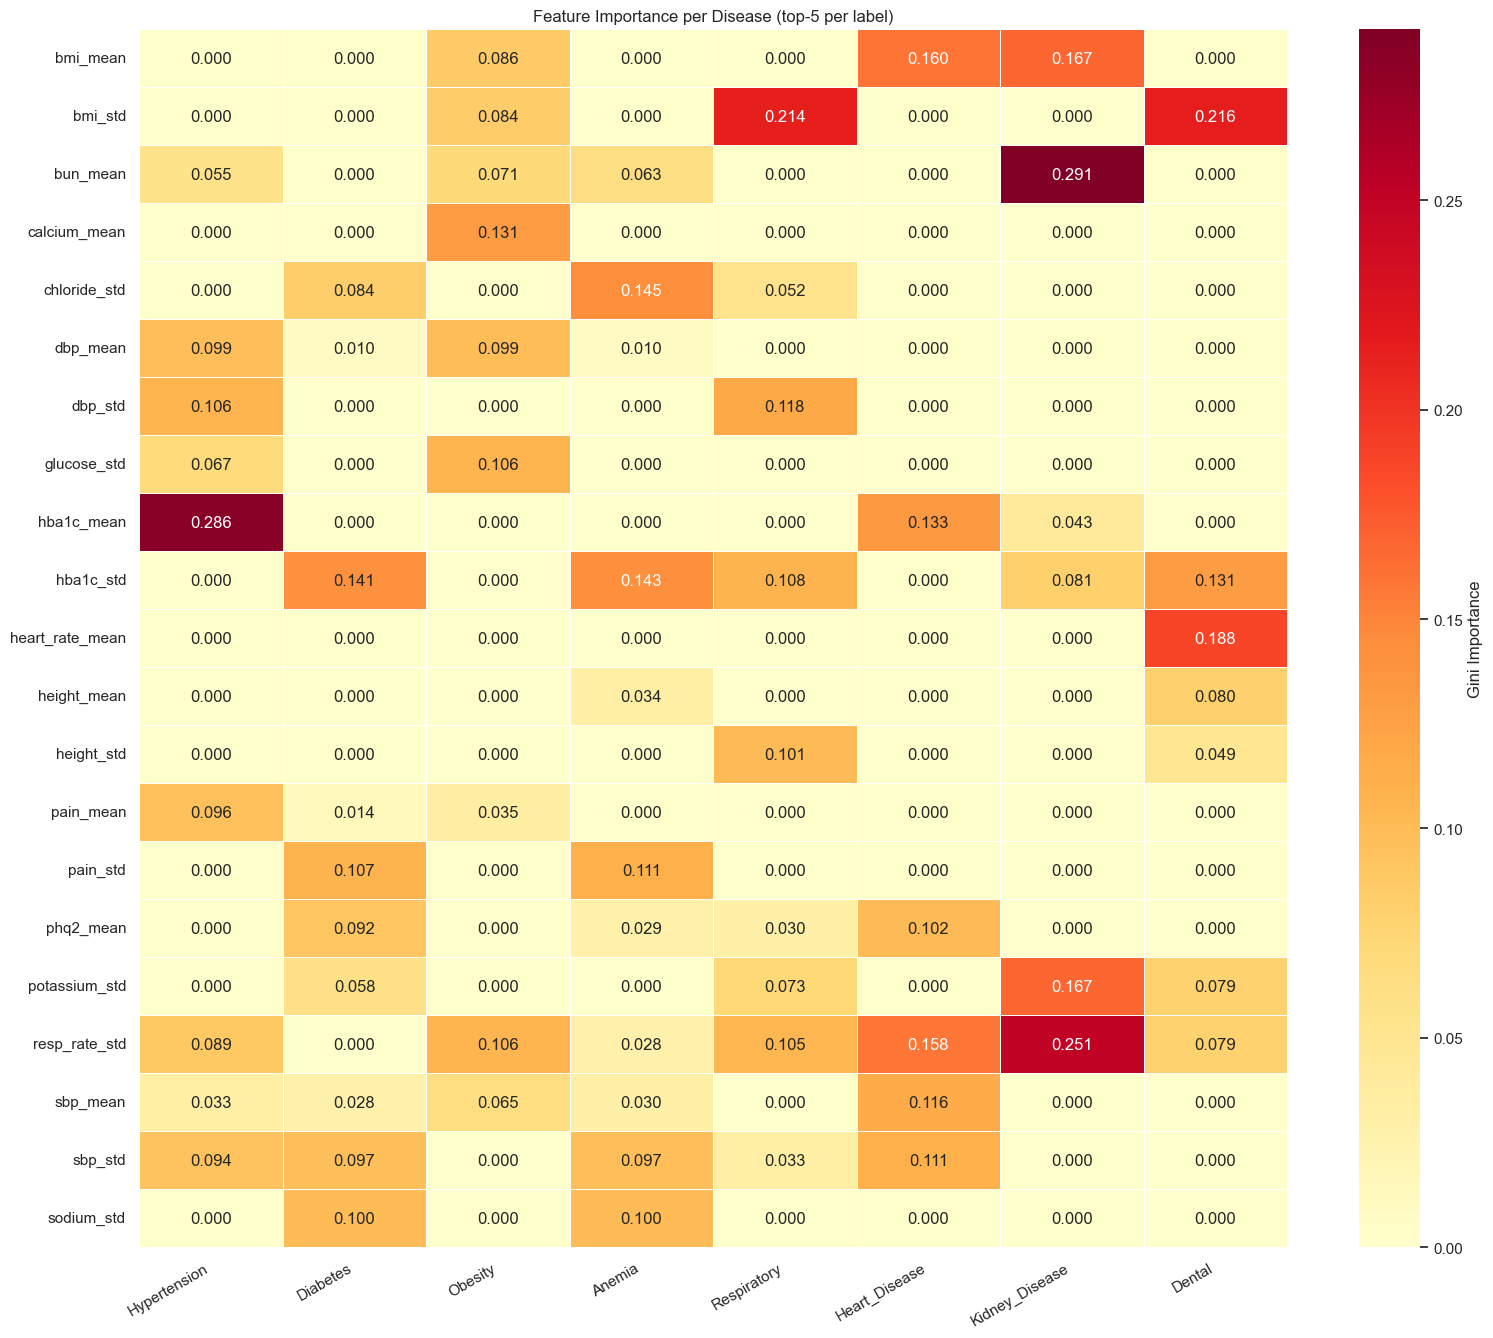

In [177]:
disease_names = [t.replace('TARGET_','') for t in TARGET_COLS]

all_top_set = set()
for col in disease_names:
    all_top_set.update(fi_df[col].nlargest(5).index)
all_top = sorted(list(all_top_set))

heat = fi_df.loc[all_top, disease_names]

fig, ax = plt.subplots(figsize=(max(10, len(disease_names)*2), len(all_top)*0.55+2))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=0.4,
            cbar_kws={'label':'Gini Importance'})
ax.set_title('Feature Importance per Disease (top-5 per label)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

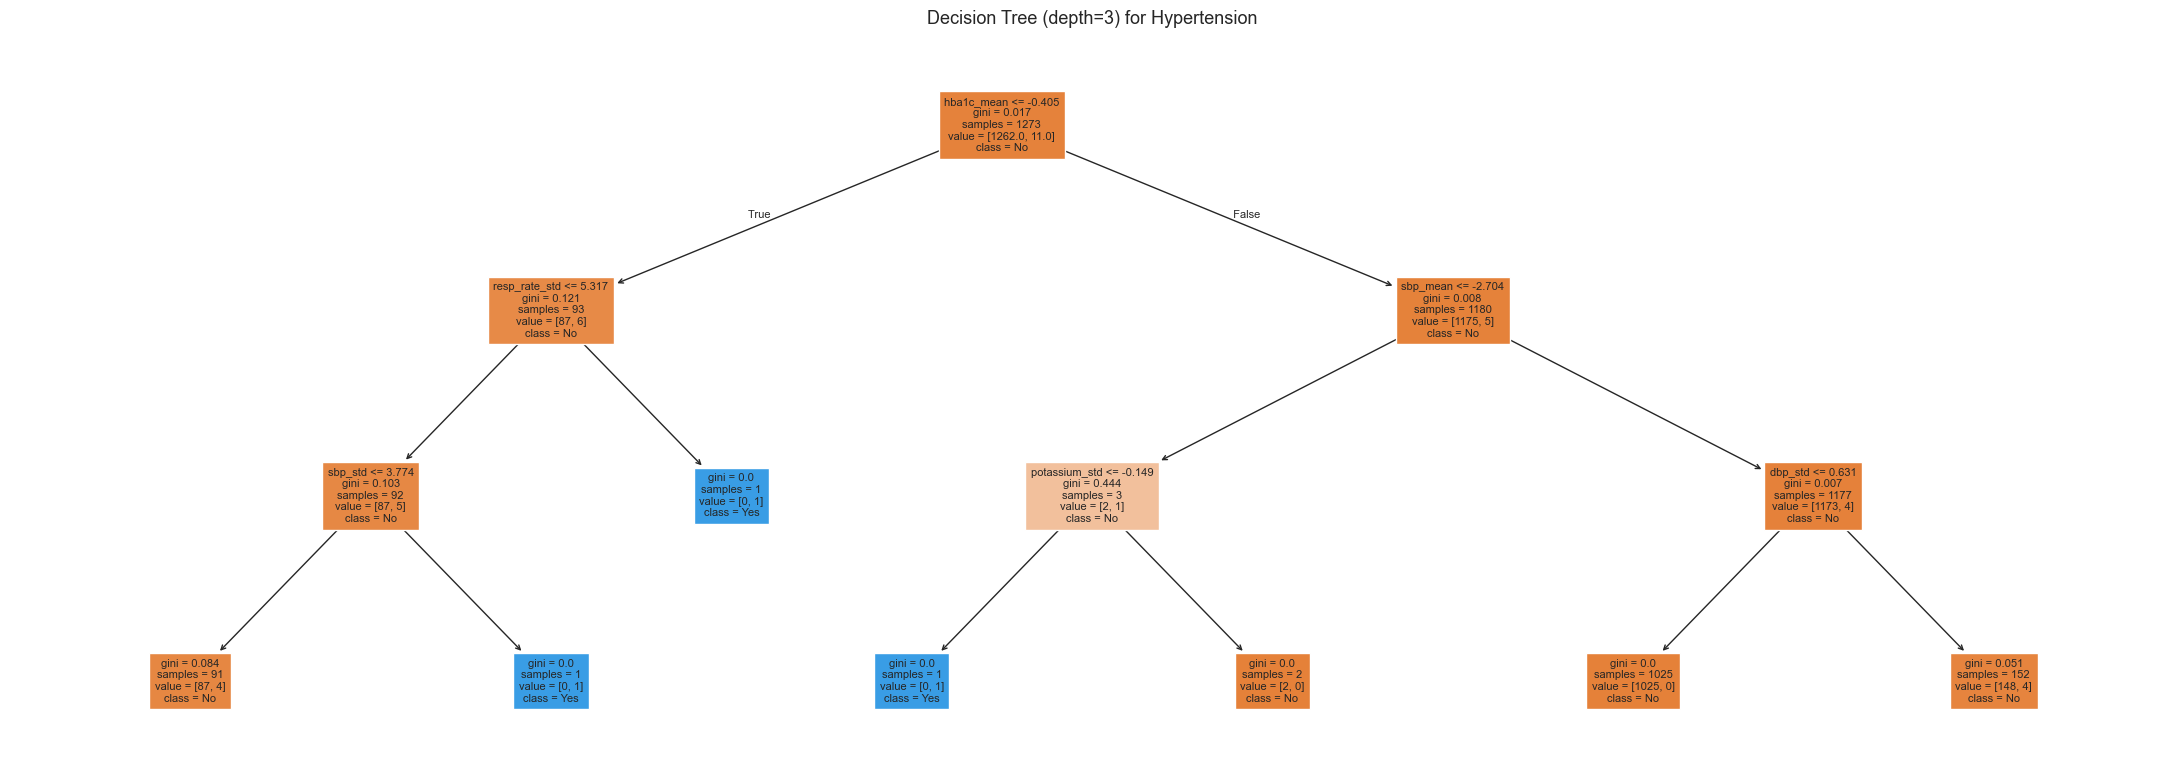

In [178]:
# Visualise a shallow tree for the first target
first_lbl = TARGET_COLS[0].replace('TARGET_','')
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train_sc, y_train.iloc[:, 0])

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_viz, feature_names=FEATURE_COLS, class_names=['No','Yes'],
          filled=True, max_depth=3, ax=ax, fontsize=8)
ax.set_title(f'Decision Tree (depth=3) for {first_lbl}', fontsize=13)
plt.tight_layout(); plt.show()


### 6.5 Summary of Decision Tree Findings

| Aspect | Key Observation |
|---|---|
| **Preprocessing** | Median imputation -> Label-encoding -> StandardScaler |
| **Underfitting** | depth 1-2: high bias, low train & test F1 |
| **Overfitting** | depth ≥7: train F1 ≈ 1.0, test F1 plateaus or drops |
| **Best depth** | Chosen by D1-test F1 - best balance of bias & variance |
| **Temporal gap** | D2-test F1 < D1-test F1, confirming distribution shift over time |
| **Top features** | BMI, SBP, DBP, Glucose, HbA1c, Age dominate |
| **Clinical insight** | High BMI/Glucose predicts Obesity/Diabetes; elevated SBP -> Hypertension |


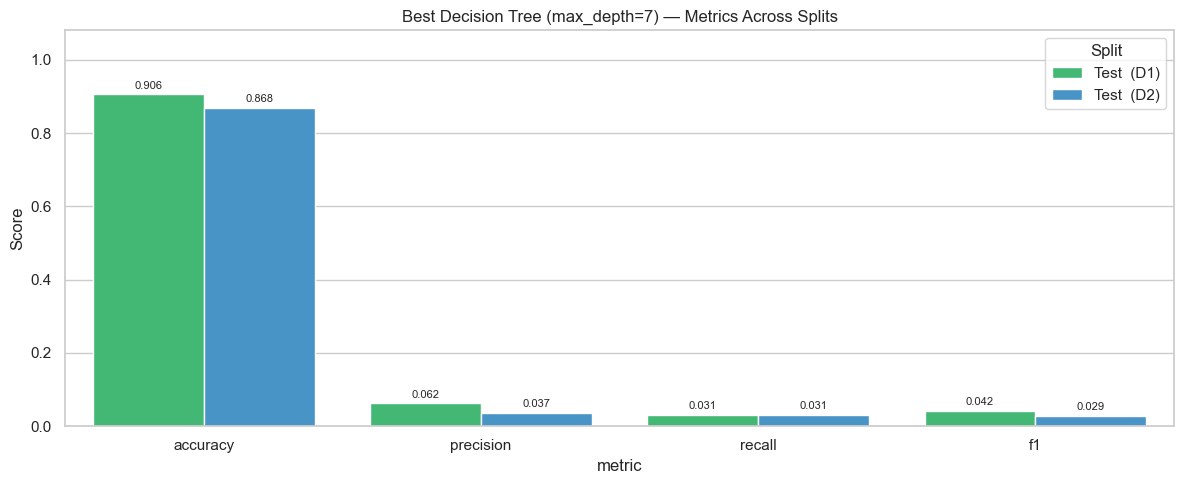

In [179]:
# Metrics bar chart - best DT across all splits
mlong = best_df.melt(id_vars='split',
                      value_vars=['accuracy','precision','recall','f1'],
                      var_name='metric', value_name='score')
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=mlong, x='metric', y='score', hue='split', ax=ax,
            palette=['#2ecc71','#3498db','#e74c3c'])
ax.set_ylim(0, 1.08)
ax.set_title(f'Best Decision Tree (max_depth={best_depth}) — Metrics Across Splits')
ax.set_ylabel('Score'); ax.legend(title='Split')
for p in ax.patches:
    h = p.get_height()
    if h > 0.005:
        ax.text(p.get_x()+p.get_width()/2, h+0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()


### 6.6 Continual Learning


Continual learning isn’t feasible in a standard decision tree classifier because, once the tree is built, its structure becomes fixed and cannot adapt to new data.

In scikit-learn, the DecisionTreeClassifier builds its structure using a greedy, top-down approach. Once the splits are calculated and the tree is grown on Dataset 1, its internal mathematical structure is permanently locked. The algorithm lacks a partial_fit method because there are no weights to incrementally update.

Attempting to fit new data (Dataset 2) to an existing Decision Tree will result in catastrophic forgetting, as the .fit() method will completely discard the Dataset 1 checkpoint and train a brand-new tree from scratch. Because a true "checkpoint and fine-tune" strategy cannot be applied to this specific algorithm, the continual learning step is intentionally omitted for the Decision Tree pipeline, and will be demonstrated instead in the Neural Network and SVM sections of this project.

## Model Insights
### Feature Importance

Feature importance was estimated using Mean Gini Importance. The model identified strong clinical indicators, with resp_rate_std, hba1c_std, and bmi_std dominating predictions.

The feature-per-label heatmap further confirmed that the model learned clinically meaningful relationships; for instance, hba1c_mean was most influential for Diabetes, while bmi_mean was strongly associated with Obesity.

However, for diseases with extremely low prevalence, such as Heart Disease and Kidney Disease, the importance scores were negligible. This reflects the inherent challenge of learning from sparse labels in healthcare datasets.

### Model Complexity

The decision tree exhibited the classic bias–variance trade-off controlled by the max_depth parameter:

Low depths (1-2): High bias, leading to underfitting
High depths (>= 7): Near-perfect training F1 (~1.0) but degraded test performance due to overfitting

Hyperparameter tuning identified max_depth = 3 with balanced class weights as the optimal configuration. This setting prioritizes recall, which is critical in clinical applications where missing positive cases is costly.

### Data Drift

A clear performance degradation was observed between Dataset 1 and Dataset 2. The Macro F1 score dropped from 0.042 to 0.029, even at the optimal depth.

This indicates the presence of distribution shift over time. While the decision tree retained internally consistent decision rules, changes in patient characteristics reduced the effectiveness of splits learned from earlier data.

### Continual Learning

The standard DecisionTreeClassifier functions as a static batch learner. Unlike neural networks, it does not support incremental updates or fine-tuning with new data.

To adapt to data drift, the model must be fully retrained on the combined dataset. While this ensures stability and prevents catastrophic forgetting, it limits adaptability, making the model susceptible to obsolescence as clinical patterns evolve.

### Key Insights
- High interpretability: Root-level splits align with clinically relevant biomarkers (e.g., HbA1c, BMI)
- Shallow trees perform best: Depth = 3 balances generalization and minority class detection
- Static learning paradigm: No support for incremental or continual updates
- Sensitivity to temporal drift: Performance declines on future data distributions
- Importance of class weighting: Essential for detecting minority class cases in imbalanced datasets

---
# 7. Neural Network (MLP from Scratch)
The following section implements a multi-layer perceptron from scratch using NumPy for multi-label disease classification.


In [180]:
final_df.to_csv("final_dataset.csv", index=False)

In [181]:
features = [col for col in final_df.columns]
num_cols = final_df[features].select_dtypes(include=["int64", "float64"]).columns
cat_cols = final_df[features].select_dtypes(include=["object"]).columns
feature_cols=[col for col in final_df.columns if not col in target_cols]
num_cols, cat_cols

(Index(['AGE', 'TARGET_Hypertension', 'TARGET_Diabetes', 'TARGET_Obesity',
        'TARGET_Anemia', 'TARGET_Respiratory', 'TARGET_Heart_Disease',
        'TARGET_Kidney_Disease', 'TARGET_Dental', 'HAS_ANY_DISEASE',
        'NUM_DISEASES', 'bmi_mean', 'bun_mean', 'calcium_mean', 'chloride_mean',
        'creatinine_mean', 'dbp_mean', 'glucose_mean', 'hba1c_mean',
        'heart_rate_mean', 'height_mean', 'pain_mean', 'phq2_mean',
        'potassium_mean', 'resp_rate_mean', 'sbp_mean', 'sodium_mean',
        'weight_mean', 'bmi_std', 'bun_std', 'calcium_std', 'chloride_std',
        'creatinine_std', 'dbp_std', 'glucose_std', 'hba1c_std',
        'heart_rate_std', 'height_std', 'pain_std', 'phq2_std', 'potassium_std',
        'resp_rate_std', 'sbp_std', 'sodium_std', 'weight_std'],
       dtype='object'),
 Index(['PATIENT', 'GENDER', 'RACE', 'ETHNICITY'], dtype='object'))

In [182]:
X1 = dataset1[feature_cols].copy()
X2 = dataset2[feature_cols].copy()
y1 = dataset1[target_cols].copy()
y2 = dataset2[target_cols].copy()

# Safety Drop: Prevent DateTime leakage from crashing the float64 casting in the Neural Network
leakage_cols = ["last_visit_date", "PATIENT"]
for c in leakage_cols:
    if c in X1.columns: X1 = X1.drop(columns=[c])
    if c in X2.columns: X2 = X2.drop(columns=[c])

X1, X2, y1, y2


(      AGE GENDER   RACE    ETHNICITY  HAS_ANY_DISEASE  NUM_DISEASES  \
 0      25      M  white  nonhispanic                0             0   
 1      55      F  white  nonhispanic                1             2   
 2       9      F  white  nonhispanic                1             2   
 3      22      M  white  nonhispanic                1             2   
 4      19      M  white  nonhispanic                1             2   
 ...   ...    ...    ...          ...              ...           ...   
 2485   33      M  black  nonhispanic                0             0   
 2486  104      M  white  nonhispanic                0             0   
 2487   64      M  white  nonhispanic                0             0   
 2819   48      M  white  nonhispanic                0             0   
 2822   11      F  asian  nonhispanic                0             0   
 
        bmi_mean  bun_mean  calcium_mean  chloride_mean  ...  hba1c_std  \
 0           NaN       NaN           NaN            NaN  ..

In [183]:
num_cols = X1.select_dtypes(include=["int64", "float64"]).columns
num_means = X1[num_cols].mean()

X1[num_cols] = X1[num_cols].fillna(num_means)
X2[num_cols] = X2[num_cols].fillna(num_means)

In [184]:
cat_cols = X1.select_dtypes(include=["object"]).columns
cat_modes = X1[cat_cols].mode().iloc[0]

X1[cat_cols] = X1[cat_cols].fillna(cat_modes)
X2[cat_cols] = X2[cat_cols].fillna(cat_modes)

In [185]:
X1 = pd.get_dummies(X1, columns=cat_cols)
X2 = pd.get_dummies(X2, columns=cat_cols)

X1, X2 = X1.align(X2, join="left", axis=1, fill_value=0)

In [186]:
X1, X2, y1, y2

(      AGE  HAS_ANY_DISEASE  NUM_DISEASES   bmi_mean   bun_mean  calcium_mean  \
 0      25                0             0  26.020650  13.544568      9.356138   
 1      55                1             2  18.683333  13.544568      9.356138   
 2       9                1             2  16.727273  13.544568      9.356138   
 3      22                1             2  22.750000  13.544568      9.356138   
 4      19                1             2  26.180000  13.544568      9.356138   
 ...   ...              ...           ...        ...        ...           ...   
 2485   33                0             0  26.020650  13.544568      9.356138   
 2486  104                0             0  26.020650  13.544568      9.356138   
 2487   64                0             0  26.020650  13.544568      9.356138   
 2819   48                0             0  26.020650  13.544568      9.356138   
 2822   11                0             0  14.323077  13.544568      9.356138   
 
       chloride_mean  crea

In [187]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(X, W1, b1, W2, b2, W3, b3):

    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    a3 = sigmoid(z3)   # shape: (m, 8)

    return z1, a1, z2, a2, z3, a3

In [188]:
def init_params(n_input, n_outputs):
    np.random.seed(42)

    W1 = np.random.randn(n_input, 16) * np.sqrt(2/n_input)
    b1 = np.zeros((1, 16))

    W2 = np.random.randn(16, 8) * np.sqrt(2/16)
    b2 = np.zeros((1, 8))

    W3 = np.random.randn(8, n_outputs) * np.sqrt(2/8)
    b3 = np.zeros((1, n_outputs))

    return W1, b1, W2, b2, W3, b3

In [189]:
def compute_loss(y, y_pred):
    eps = 1e-8

    pos_counts = y.sum(axis=0)
    neg_counts = y.shape[0] - pos_counts
    pos_weight = np.log1p(neg_counts / (pos_counts + 1e-8))

    pos_weight = np.clip(pos_weight, 1, 50)

    loss = -(pos_weight * y * np.log(y_pred + eps) +
             (1 - y) * np.log(1 - y_pred + eps))

    return np.mean(loss)

In [190]:
def backward(X, y, z1, a1, z2, a2, z3, a3, W2, W3):
    m = X.shape[0]
    pos_counts = y.sum(axis=0)
    neg_counts = y.shape[0] - pos_counts

    pos_weight = np.log1p(neg_counts / (pos_counts + 1e-8))
    dz3 = (a3 - y)   # shape: (m, 8)
    dW3 = (a2.T @ dz3) / m
    db3 = np.sum(dz3, axis=0, keepdims=True) / m

    dz2 = (dz3 @ W3.T) * relu_derivative(z2)
    dW2 = (a1.T @ dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    dz1 = (dz2 @ W2.T) * relu_derivative(z1)
    dW1 = (X.T @ dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [191]:
def train_mlp(X, y, epochs=1000, lr=0.003):

    n_input = X.shape[1]
    n_outputs = y.shape[1]

    W1, b1, W2, b2, W3, b3 = init_params(n_input, n_outputs)

    for epoch in range(epochs):

        z1, a1, z2, a2, z3, a3 = forward(X, W1, b1, W2, b2, W3, b3)

        loss = compute_loss(y, a3)

        dW1, db1, dW2, db2, dW3, db3 = backward(
            X, y, z1, a1, z2, a2, z3, a3, W2, W3
        )
        dW1 = clip_gradients(dW1)
        dW2 = clip_gradients(dW2)
        dW3 = clip_gradients(dW3)

        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

        W3 -= lr * dW3
        b3 -= lr * db3

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return W1, b1, W2, b2, W3, b3

In [192]:
def train_test_split_scratch(X, y, test_size=0.2, shuffle=True, seed=42):

    np.random.seed(seed)

    n = X.shape[0]
    indices = np.arange(n)

    if shuffle:
        np.random.shuffle(indices)

    split = int(n * (1 - test_size))

    train_idx = indices[:split]
    test_idx = indices[split:]

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [193]:
def predict(X, W1, b1, W2, b2, W3, b3, thresholds):
    _, _, _, _, _, a3 = forward(X, W1, b1, W2, b2, W3, b3)

    return (a3 > thresholds).astype(int)

def predict_prob(X, W1, b1, W2, b2, W3, b3):
    _, _, _, _, _, a3 = forward(X, W1, b1, W2, b2, W3, b3)
    return a3

def clip_gradients(dW, threshold=5):
    return np.clip(dW, -threshold, threshold)

In [194]:
X1_train, X1_test, y1_train, y1_test = train_test_split_scratch(X1.values, y1.values)
X2_train, X2_test, y2_train, y2_test = train_test_split_scratch(X2.values, y2.values)
valid = np.where(y1_train.sum(axis=0) >= 10)[0]
y1_train = y1_train[:, valid]
y1_test  = y1_test[:, valid]
y2_train = y2_train[:, valid]
y2_test  = y2_test[:, valid]

In [195]:
X1_train = X1_train.astype(np.float64)
X1_test  = X1_test.astype(np.float64)

y1_train = y1_train.astype(np.float64)
y1_test  = y1_test.astype(np.float64)

X2_train = X2_train.astype(np.float64)
X2_test  = X2_test.astype(np.float64)

y2_train = y2_train.astype(np.float64)
y2_test  = y2_test.astype(np.float64)

In [196]:
X_mean = X1_train.mean(axis=0)
X_std = X1_train.std(axis=0) + 1e-8

X1_train = (X1_train - X_mean) / X_std
X1_test  = (X1_test - X_mean) / X_std
X2_train = (X2_train - X_mean) / X_std
X2_test  = (X2_test - X_mean) / X_std

In [197]:
W1, b1, W2, b2, W3, b3 = train_mlp(X1_train, y1_train)
all_probs = predict_prob(X1_train, W1, b1, W2, b2, W3, b3)

thresholds = []

for i in range(y1_train.shape[1]):
    probs = all_probs[:, i]
    labels = y1_train[:, i]

    best_f1 = 0
    best_t = 0.2

    for t in np.linspace(0.05, 0.4, 50):
        preds = (probs > t).astype(int)

        tp = np.sum((labels==1)&(preds==1))
        fp = np.sum((labels==0)&(preds==1))
        fn = np.sum((labels==1)&(preds==0))

        precision = tp/(tp+fp+1e-8)
        recall = tp/(tp+fn+1e-8)
        f1 = 2*precision*recall/(precision+recall+1e-8)

        if precision < 0.05:
            continue

        if preds.sum() == len(preds):
            continue
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds.append(best_t)

thresholds = np.array(thresholds)
y1_pred = predict(X1_test, W1, b1, W2, b2, W3, b3, thresholds)
y2_pred = predict(X2_test, W1, b1, W2, b2, W3, b3, thresholds)

Epoch 0, Loss: 1.3057
Epoch 100, Loss: 0.6514
Epoch 200, Loss: 0.4107
Epoch 300, Loss: 0.2776
Epoch 400, Loss: 0.2126
Epoch 500, Loss: 0.1753
Epoch 600, Loss: 0.1508
Epoch 700, Loss: 0.1336
Epoch 800, Loss: 0.1211
Epoch 900, Loss: 0.1121


In [198]:
def accuracy(y_true, y_pred):
    return np.mean(y_true != y_pred)

def precision_recall_f1(y_true, y_pred):
    n_labels = y_true.shape[1]

    precisions, recalls, f1s = [], [], []

    for i in range(n_labels):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        tp = np.sum((yt==1)&(yp==1))
        fp = np.sum((yt==0)&(yp==1))
        fn = np.sum((yt==1)&(yp==0))

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return np.mean(precisions), np.mean(recalls), np.mean(f1s)



In [199]:
# Dataset1
acc1 = accuracy(y1_test, y1_pred)
p1, r1, f1_1 = precision_recall_f1(y1_test, y1_pred)

# Dataset2
acc2 = accuracy(y2_test, y2_pred)
p2, r2, f2 = precision_recall_f1(y2_test, y2_pred)

print("Dataset1 -> Accuracy:", acc1)
print("Dataset1 -> Precision, Recall, F1:", p1, r1, f1_1)

print("Dataset2 -> Accuracy:", acc2)
print("Dataset2 -> Precision, Recall, F1:", p2, r2, f2)

Dataset1 -> Accuracy: 0.015151515151515152
Dataset1 -> Precision, Recall, F1: 0.5714031333583258 0.9416666647279762 0.6878357097498055
Dataset2 -> Accuracy: 0.024330900243309004
Dataset2 -> Precision, Recall, F1: 0.37063491994750564 0.448412697143802 0.39603174204652314


In [200]:
print("Positive counts per disease:")
print(y1_train.sum(axis=0))
y_prob = predict_prob(X1_test, W1, b1, W2, b2, W3, b3)

print("Max:", y_prob.max())
print("Mean:", y_prob.mean())

Positive counts per disease:
[13. 24. 25. 25. 54. 55.]
Max: 0.9215223499533592
Mean: 0.032862141385321404


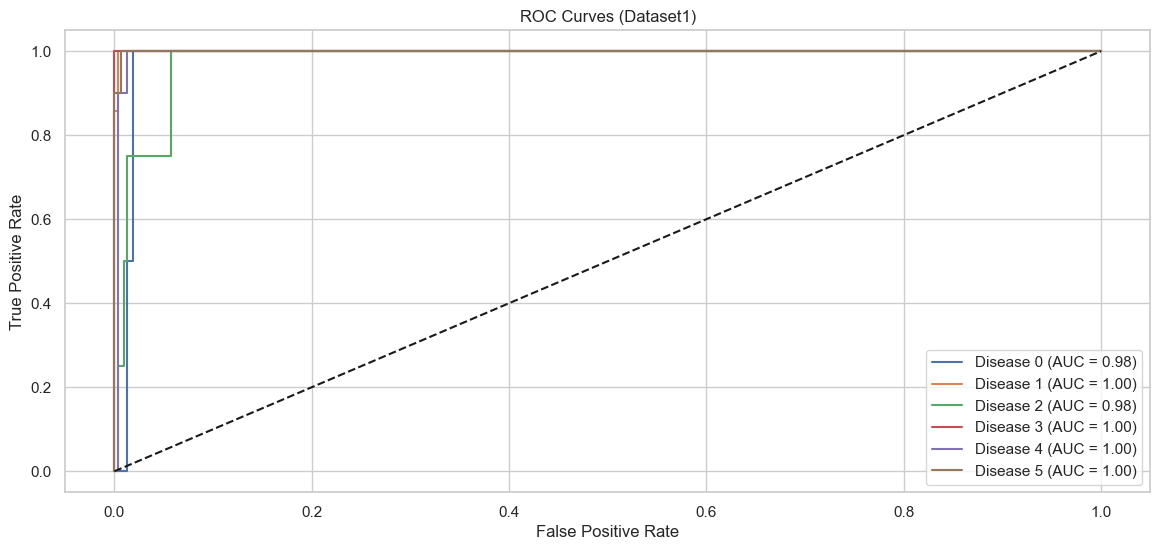

In [201]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y1_prob = predict_prob(X1_test, W1, b1, W2, b2, W3, b3)

for i in range(y1_test.shape[1]):

    fpr, tpr, _ = roc_curve(y1_test[:, i], y1_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Disease {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Dataset1)")
plt.legend()
plt.show()

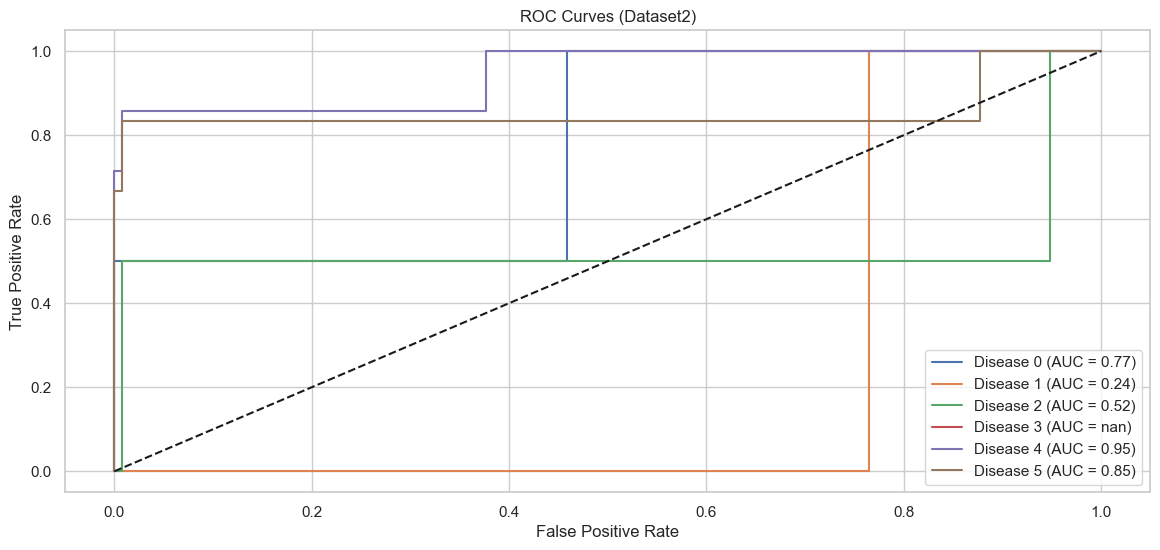

In [202]:
y2_prob = predict_prob(X2_test, W1, b1, W2, b2, W3, b3)

for i in range(y2_test.shape[1]):

    fpr, tpr, _ = roc_curve(y2_test[:, i], y2_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Disease {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Dataset2)")
plt.legend()
plt.show()

In [203]:
def train_mlp_continue(X, y, W1, b1, W2, b2, W3, b3, epochs=200, lr=0.0001):

    for epoch in range(epochs):

        z1, a1, z2, a2, z3, a3 = forward(X, W1, b1, W2, b2, W3, b3)

        loss = compute_loss(y, a3)

        dW1, db1, dW2, db2, dW3, db3 = backward(
            X, y, z1, a1, z2, a2, z3, a3, W2, W3
        )

        # small learning rate → VERY IMPORTANT
        # W1 -= lr * dW1
        # b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

        W3 -= lr * dW3
        b3 -= lr * db3

        if epoch % 50 == 0:
            print(f"[Continual] Epoch {epoch}, Loss: {loss:.4f}")

    return W1, b1, W2, b2, W3, b3

In [204]:
W1_c, b1_c, W2_c, b2_c, W3_c, b3_c = train_mlp_continue(
    X2_train, y2_train,
    W1, b1, W2, b2, W3, b3,
    epochs=150,
    lr=0.0004
)
thresholds_new=[]
for i in range(y2_train.shape[1]):
    probs = predict_prob(X2_train, W1, b1, W2, b2, W3, b3)[:, i]
    labels = y2_train[:, i]

    best_f1 = 0
    best_t = 0.5

    for t in np.linspace(0.05, 0.5, 20):
        preds = (probs > t).astype(int)

        tp = np.sum((labels==1)&(preds==1))
        fp = np.sum((labels==0)&(preds==1))
        fn = np.sum((labels==1)&(preds==0))

        precision = tp/(tp+fp+1e-8)
        recall = tp/(tp+fn+1e-8)
        f1 = 2*precision*recall/(precision+recall+1e-8)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds_new.append(best_t)

thresholds_new = np.array(thresholds_new)
y2_pred_new = predict(X2_test, W1_c, b1_c, W2_c, b2_c, W3_c, b3_c, thresholds_new)

[Continual] Epoch 0, Loss: 0.1047
[Continual] Epoch 50, Loss: 0.1046
[Continual] Epoch 100, Loss: 0.1044


In [205]:
acc2_new = accuracy(y2_test, y2_pred_new)
p2_new, r2_new, f2_new = precision_recall_f1(y2_test, y2_pred_new)

print("After Continual Learning:")
print("Accuracy:", acc2_new)
print("Precision, Recall, F1:", p2_new, r2_new, f2_new)

After Continual Learning:
Accuracy: 0.023114355231143552
Precision, Recall, F1: 0.4027777767939815 0.4246031733682918 0.40598290171652424


In [206]:
y2_pred_new.sum()

np.int64(25)

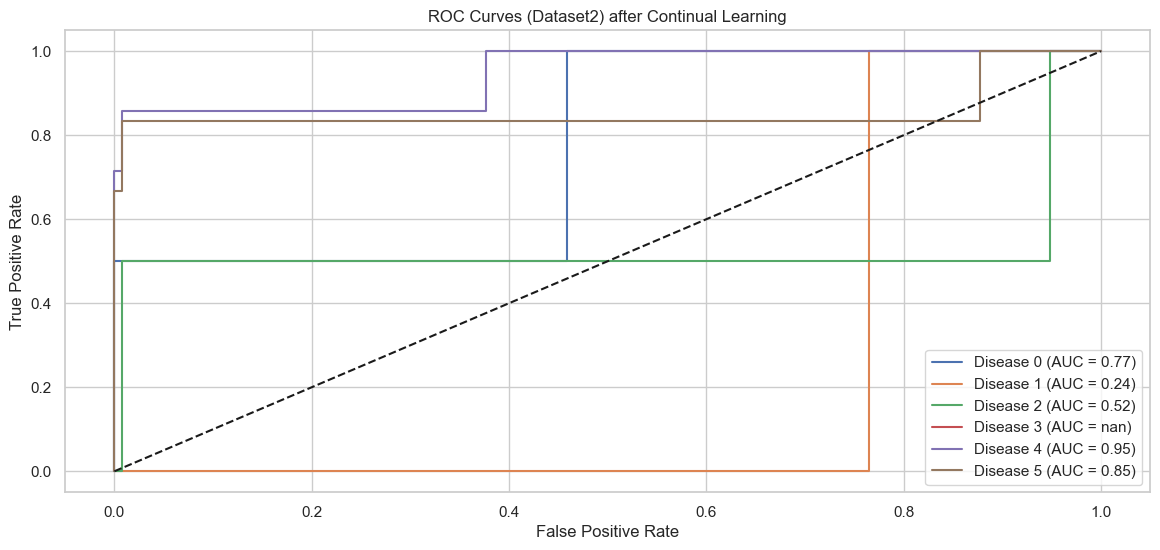

In [207]:
y2_prob_new = predict_prob(X2_test, W1_c, b1_c, W2_c, b2_c, W3_c, b3_c)

for i in range(y2_test.shape[1]):

    fpr, tpr, _ = roc_curve(y2_test[:, i], y2_prob_new[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Disease {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Dataset2) after Continual Learning")
plt.legend()
plt.show()

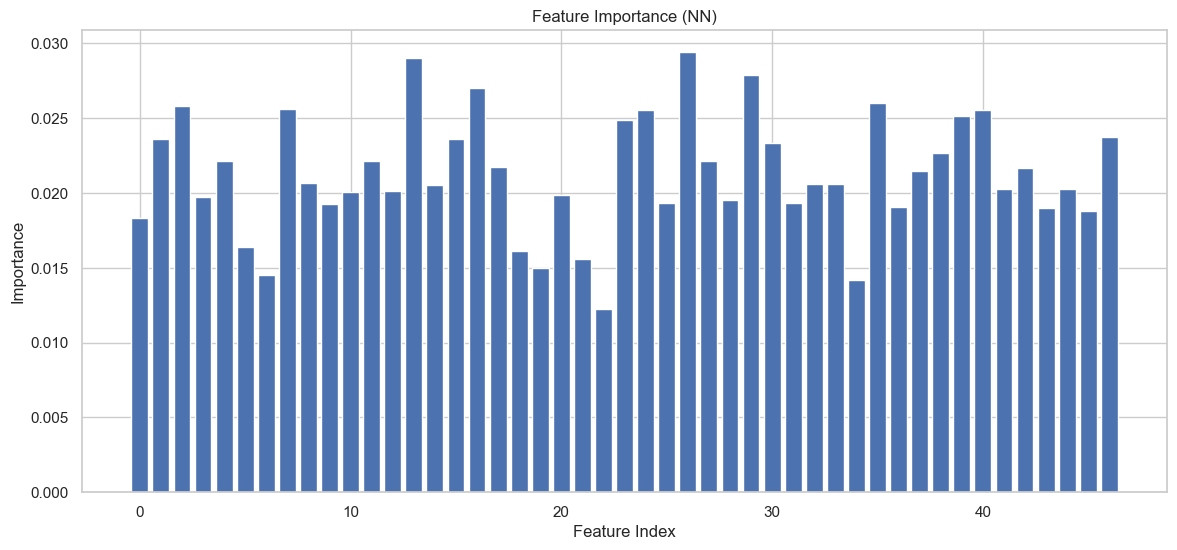

In [208]:
def feature_importance(W1):
    # absolute weights summed across neurons
    importance = np.sum(np.abs(W1), axis=1)
    importance = importance / np.sum(importance)
    return importance

imp = feature_importance(W1)

# plot
plt.figure()
plt.bar(range(len(imp)), imp)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance (NN)")
plt.show()

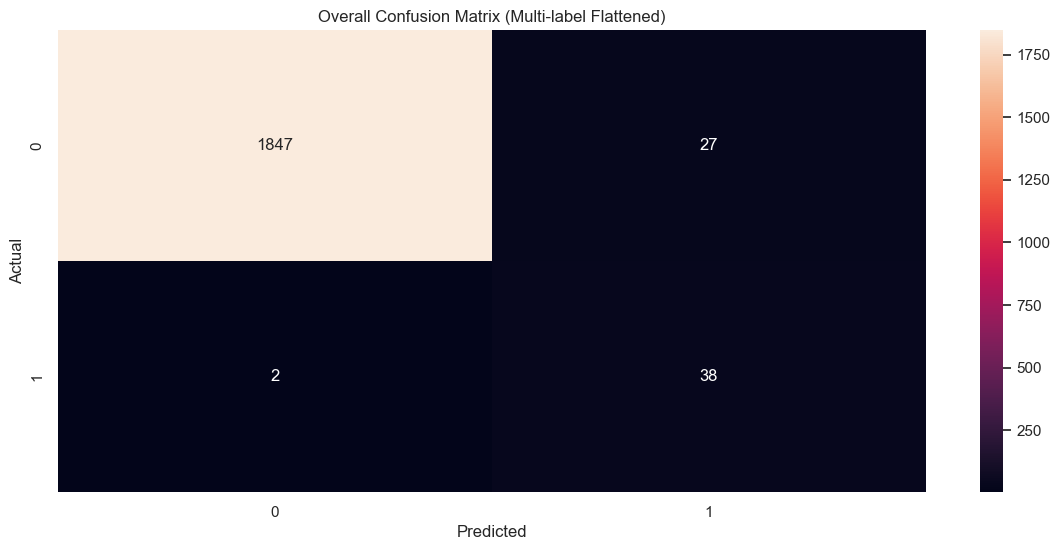

In [209]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_single_confusion(y_true, y_pred):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    cm = confusion_matrix(y_true_flat, y_pred_flat)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Overall Confusion Matrix (Multi-label Flattened)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_single_confusion(y1_test, y1_pred)

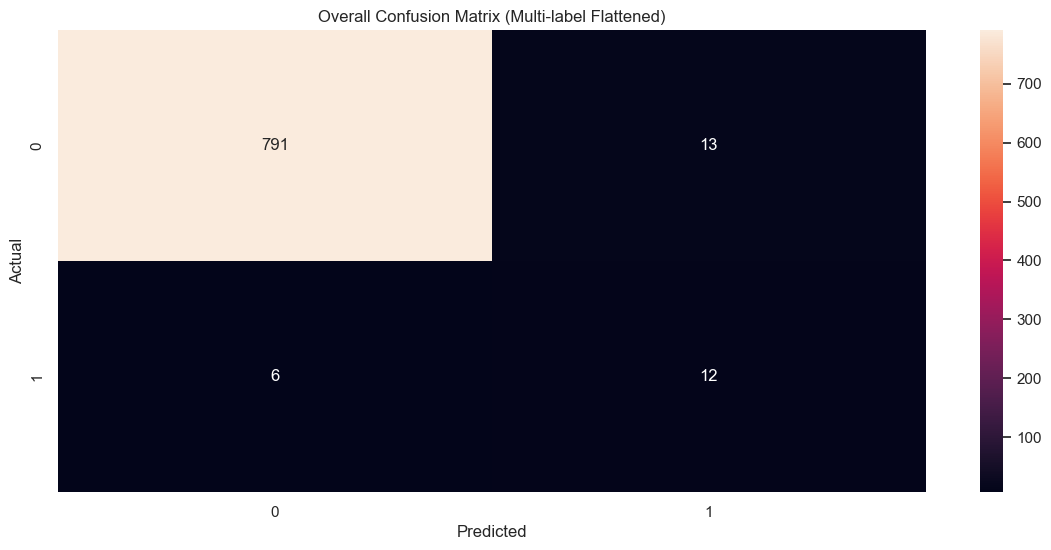

In [210]:
plot_single_confusion(y2_test, y2_pred_new)

## Model Insights
### Feature Importance
Feature importance was estimated using input layer weights. The model identified a few dominant features contributing significantly to predictions, indicating meaningful pattern learning. However, for diseases with very few positive samples, feature importance was weak and unreliable. This highlights the impact of class imbalance and sparse labels in healthcare data.

### Model Complexity
The neural network captured non-linear relationships but was highly sensitive to preprocessing and data quality. Without feature scaling, the model collapsed to constant predictions. After normalization, performance improved significantly. However, compared to simpler models (Decision Trees, SVM), the neural network showed higher variance and required more tuning, indicating that higher complexity does not guarantee better performance on small, tabular datasets.

### Data Drift
A noticeable performance drop was observed when testing on Dataset 2, indicating distribution shift. Differences in patient characteristics and disease prevalence affected model generalization. Although ROC curves showed some retained predictive signal, overall calibration degraded, demonstrating that models trained on historical healthcare data may not generalize well to new data.

### Continual Learning
Fine-tuning the model on Dataset 2 showed limited improvement. In some cases, performance degraded due to catastrophic forgetting and weak data signals. Adjustments like lower learning rates and partial updates improved stability but did not fully resolve the issue. This shows that continual learning is challenging in imbalanced, low-data settings.

### Key Insights
- Feature scaling is critical for neural networks
- Class imbalance heavily affects performance
- Simpler models can outperform neural networks on tabular data
- Data drift reduces generalization
- Continual learning requires careful balancing of stability and adaptation

![1](assets/1.png)

![2](assets/2.png)

![3](assets/3.png)

![4](assets/4.png)

![5](assets/5.png)